# Astrometric concordance after the v8 latent position head

How well do Rubin and Euclid NISP each align to Euclid VIS after our
per-object latent position head runs, and what is left over for a smooth concordance field
to correct? This notebook walks through the answer on ECDFS (790 tiles,
~630k matched anchors across all 9 non-VIS bands -- 6 Rubin ugrizy + 3 Euclid NISP YJH -- each aligned to Euclid VIS).

**What you'll see**

1. **Before / after summary.** Per-band bar chart, radial histograms and
   decomposed vector statistics comparing raw WCS, a smooth PINN field
   on raw anchors, the head correction, and a smooth PINN field on the
   head residual. Establishes the headline numbers.
2. **Spatial field maps.** 9 bands x 4 sky-binned columns: raw-anchor
   offsets, PINN raw, head-residual offsets, PINN after head. Confirms
   that the head absorbs the coherent structure anchor-by-anchor.
3. **Anchor population.** Per-band SNR distributions, spatial density by
   SNR tercile and per-tile bright-anchor counts. Characterizes how much
   a classical bright-only concordance workflow has to work with.
4. **SNR-stratified PINN refits.** Refit the PINN on `bright`, `mid` and
   `faint` slices (per-band terciles) of the raw anchors and separately
   of the head-residual anchors. Exposes how the measured field
   amplitude depends on anchor SNR and whether the head's denoising is
   SNR-independent.
5. **Sparse-field recovery.** Can faint sources alone reproduce the
   smooth field that bright stars pin down classically? And does the
   head's own per-source prediction act as a dense sampling of that
   same smooth field?

**Scope.** Every figure and table below pools matches from all 9 bands: Rubin ugrizy to VIS and NISP YJH to VIS. Rubin and NISP sit on different native pixel grids (0.2"/px and 0.1"/px) and have different PSFs, so their centroid-noise floors differ; the SNR stratification below is computed per-band so those differences do not bias the slice comparisons.

**Why this matters.** ECDFS is anchor-rich, so a classical bright-only
concordance fit already reaches ~5 mas. In sparser fields (shallow
footprints, high galactic latitude gaps, few unsaturated stars) the
bright-anchor count per tile drops sharply. If the latent head can
convert faint galaxies into usable anchors, we can measure concordance
where bright stars are not available.


In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import map_coordinates
from scipy.stats import binned_statistic_2d

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.origin"] = "lower"


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / "models").exists() and (cand / "io").exists():
            return cand
    return start


ROOT = find_repo_root()
MODELS = ROOT / "models"
if str(MODELS) not in sys.path:
    sys.path.insert(0, str(MODELS))

from astrometry2.pinn_field_solver import evaluate_pinn_mesh, fit_pinn_field
from astrometry2.fit_direct_pinn import sky_to_tangent_plane

CKPT = ROOT / "models" / "checkpoints" / "latent_position_v8_no_psf"
OUT_DIR = ROOT / "io"

# Anchor cache. Auto-prefer CenterNet-detected anchors when present, else fall back to
# the original classical-detected anchors. Override either way with ANCHORS_FILE=... env var.
import os as _os
_default_anchors = "anchors_centernet.npz" if (CKPT / "anchors_centernet.npz").exists() else "anchors.npz"
ANCHORS_FILE_NAME = _os.environ.get("ANCHORS_FILE", _default_anchors)
ANCHORS_PATH = CKPT / ANCHORS_FILE_NAME
FITS_PINN_RAW = CKPT / "concordance_pinn_raw_fixed.fits"
FITS_PINN_HEAD = CKPT / "concordance_pinn_head_resid_fixed.fits"
FITS_NN_RAW = CKPT / "concordance_nn_raw_v2_fixed.fits"

for label, p in [
    (f"Anchors ({ANCHORS_FILE_NAME})", ANCHORS_PATH),
    ("PINN raw FITS", FITS_PINN_RAW),
    ("PINN head-resid FITS", FITS_PINN_HEAD),
    ("NN raw FITS", FITS_NN_RAW),
]:
    rel = p.relative_to(ROOT) if p.exists() else p
    print(f"{label:22s}: {rel}  {'OK' if p.exists() else 'MISSING'}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch device          : {DEVICE}")

# Band order and short / FITS-extension / anchors-key mapping.
RUBIN_BANDS = ["u", "g", "r", "i", "z", "y"]
NISP_BANDS = ["nisp_Y", "nisp_J", "nisp_H"]
ALL_BANDS = RUBIN_BANDS + NISP_BANDS

# Band index for the PINN chromatic embedding (matches dataset.BAND_TO_IDX).
BAND_TO_IDX = {
    "u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "y": 5,
    "nisp_Y": 6, "nisp_J": 7, "nisp_H": 8,
}
N_BANDS = 9


def display_band(b: str) -> str:
    return b.replace("nisp_", "NISP ")


def fits_ext(b: str) -> str:
    return b.replace("nisp_", "NISP_") if b.startswith("nisp_") else b.upper()


def mag_mas(offset_arcsec: np.ndarray) -> np.ndarray:
    return np.hypot(offset_arcsec[:, 0], offset_arcsec[:, 1]) * 1000.0


def med_mas(offset_arcsec: np.ndarray) -> float:
    return float(np.nanmedian(mag_mas(offset_arcsec)))


def p68_mas(offset_arcsec: np.ndarray) -> float:
    return float(np.nanpercentile(mag_mas(offset_arcsec), 68.0))


def mad_sigma(x: np.ndarray) -> float:
    return 1.4826 * float(np.nanmedian(np.abs(x - np.nanmedian(x))))


def vector_stats(arr_arcsec: np.ndarray) -> dict:
    arr_mas = np.asarray(arr_arcsec) * 1000.0
    mag = np.hypot(arr_mas[:, 0], arr_mas[:, 1])
    sys_ = np.hypot(np.nanmedian(arr_mas[:, 0]), np.nanmedian(arr_mas[:, 1]))
    return {
        "sys": float(sys_),
        "med": float(np.nanmedian(mag)),
        "p68": float(np.nanpercentile(mag, 68.0)),
        "mad_ra": mad_sigma(arr_mas[:, 0]),
        "mad_de": mad_sigma(arr_mas[:, 1]),
    }


## Part 1 -- Before / after summary

Load the anchor cache, sample the precomputed PINN fields at each source
position, and produce the headline bar chart, radial histograms and
decomposed statistics. Every number is in milliarcseconds.


In [2]:
anchors = np.load(ANCHORS_PATH, allow_pickle=True)
print(f"anchors.npz keys: {len(anchors.files)}")
for k in sorted(anchors.files)[:6]:
    print(f"  {k}: shape={anchors[k].shape} dtype={anchors[k].dtype}")
print("  ...")


def sample_field_at_sources(fits_path: Path, band: str, ra, dec) -> np.ndarray | None:
    ext = fits_ext(band)
    with fits.open(fits_path) as hdul:
        try:
            dra_hdu = hdul[f"{ext}.DRA"]
            dde_hdu = hdul[f"{ext}.DDE"]
        except KeyError:
            return None
        dra_map = np.asarray(dra_hdu.data, dtype=np.float64)
        dde_map = np.asarray(dde_hdu.data, dtype=np.float64)
        w = WCS(dra_hdu.header, naxis=2)
    px, py = w.wcs_world2pix(np.asarray(ra), np.asarray(dec), 0)
    coords = np.stack([py, px], axis=0)
    dra = map_coordinates(dra_map, coords, order=1, mode="nearest")
    dde = map_coordinates(dde_map, coords, order=1, mode="nearest")
    return np.stack([dra, dde], axis=1).astype(np.float32)


data = {}
header_fmt = (
    f'{"Band":>8} {"N":>8}  {"Raw":>8} {"Raw+PINN":>9} {"Head":>8} '
    f'{"Head+PINN":>10}  {"|Fraw|":>8} {"|Fhead|":>8}'
)
print("\n" + header_fmt)
print("-" * 88)
for band in ALL_BANDS:
    if f"{band}_raw" not in anchors or f"{band}_head_resid" not in anchors:
        print(f"{display_band(band):>8}  missing in anchors, skipping")
        continue
    ra = anchors[f"{band}_ra"]
    dec = anchors[f"{band}_dec"]
    raw = anchors[f"{band}_raw"].astype(np.float32)
    head = anchors[f"{band}_head_resid"].astype(np.float32)
    snr = (anchors[f"{band}_snr"]
           if f"{band}_snr" in anchors.files else np.full(len(raw), np.nan, dtype=np.float32))
    tiles = (anchors[f"{band}_tiles"]
             if f"{band}_tiles" in anchors.files else np.full(len(raw), "", dtype=object))
    raw_field = sample_field_at_sources(FITS_PINN_RAW, band, ra, dec)
    head_field = sample_field_at_sources(FITS_PINN_HEAD, band, ra, dec)
    raw_pinn = (raw - raw_field) if raw_field is not None else None
    head_pinn = (head - head_field) if head_field is not None else None
    # Also compute what the head predicted per source (= raw - head_resid).
    head_pred = (raw - head).astype(np.float32)
    data[band] = {
        "ra": ra, "dec": dec,
        "raw": raw, "head": head, "head_pred": head_pred, "snr": snr, "tiles": tiles,
        "raw_field": raw_field, "head_field": head_field,
        "raw_pinn": raw_pinn, "head_pinn": head_pinn,
        "n": len(raw),
    }
    print(
        f'{display_band(band):>8} {len(raw):8d}  '
        f'{med_mas(raw):8.1f} '
        f'{med_mas(raw_pinn) if raw_pinn is not None else np.nan:9.1f} '
        f'{med_mas(head):8.1f} '
        f'{med_mas(head_pinn) if head_pinn is not None else np.nan:10.1f}  '
        f'{med_mas(raw_field) if raw_field is not None else np.nan:8.1f} '
        f'{med_mas(head_field) if head_field is not None else np.nan:8.1f}'
    )

bands_present = [b for b in ALL_BANDS if b in data]
print(f"\n{len(bands_present)} bands loaded")


anchors.npz keys: 54
  g_dec: shape=(60148,) dtype=float32
  g_head_resid: shape=(60148, 2) dtype=float32
  g_ra: shape=(60148,) dtype=float32
  g_raw: shape=(60148, 2) dtype=float32
  g_snr: shape=(60148,) dtype=float32
  g_tiles: shape=(60148,) dtype=<U64
  ...

    Band        N       Raw  Raw+PINN     Head  Head+PINN    |Fraw|  |Fhead|
----------------------------------------------------------------------------------------
       u    12347     119.4     119.2     30.5       30.3       9.2      1.1
       g    60148      54.0      53.8     11.4       11.4       4.9      0.7
       r    70022      45.7      45.6     10.4       10.4       4.9      0.8
       i    62232      41.2      41.1     10.3       10.2       5.1      0.9
       z    42980      41.9      41.7     10.9       10.8       5.0      1.0
       y    17126      61.5      60.9     14.7       14.5       5.9      1.6
  NISP Y   116572      41.3      40.7      9.4        9.4       7.3      0.9
  NISP J   126352      41.9   

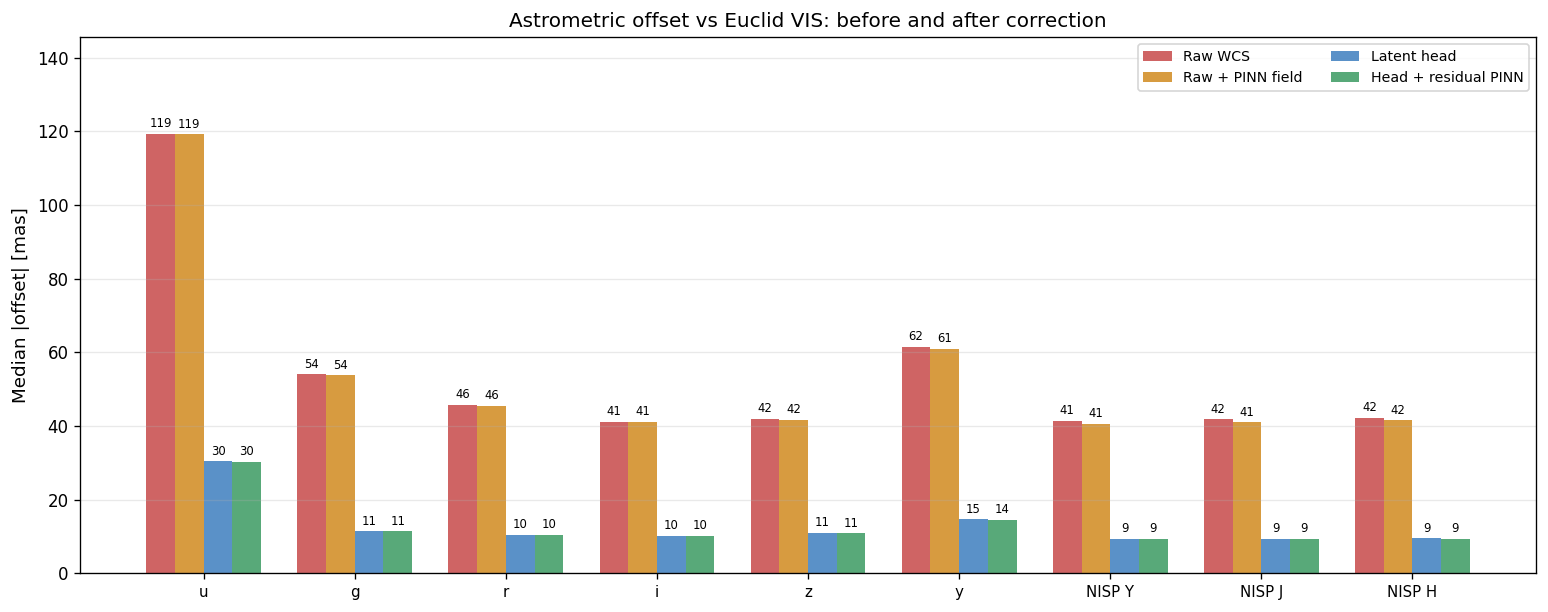

In [3]:
# Bar chart: Raw vs Raw+PINN vs Head vs Head+PINN.
x = np.arange(len(bands_present))
width = 0.19
series = [
    ("Raw WCS", "raw", "#c84b4b"),
    ("Raw + PINN field", "raw_pinn", "#d18b20"),
    ("Latent head", "head", "#3f7fbf"),
    ("Head + residual PINN", "head_pinn", "#3d9b63"),
]
values = {
    key: [med_mas(data[b][key]) if data[b][key] is not None else np.nan for b in bands_present]
    for _, key, _ in series
}

fig, ax = plt.subplots(figsize=(13, 5.2))
for i, (label, key, color) in enumerate(series):
    xpos = x + (i - 1.5) * width
    bars = ax.bar(xpos, values[key], width, label=label, color=color, alpha=0.86)
    for bar, val in zip(bars, values[key]):
        if not np.isfinite(val):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.0,
            f"{val:.0f}",
            ha="center", va="bottom", fontsize=7,
        )
ax.set_xticks(x)
ax.set_xticklabels([display_band(b) for b in bands_present], fontsize=9)
ax.set_ylabel("Median |offset| [mas]", fontsize=11)
ax.set_title("Astrometric offset vs Euclid VIS: before and after correction")
ax.legend(fontsize=8.5, ncol=2, loc="upper right")
ax.grid(axis="y", alpha=0.28)
ax.set_ylim(0, max(values["raw"]) * 1.22)
plt.tight_layout()
plt.savefig(OUT_DIR / "astrometry_before_after.png", dpi=220, bbox_inches="tight")
plt.show()


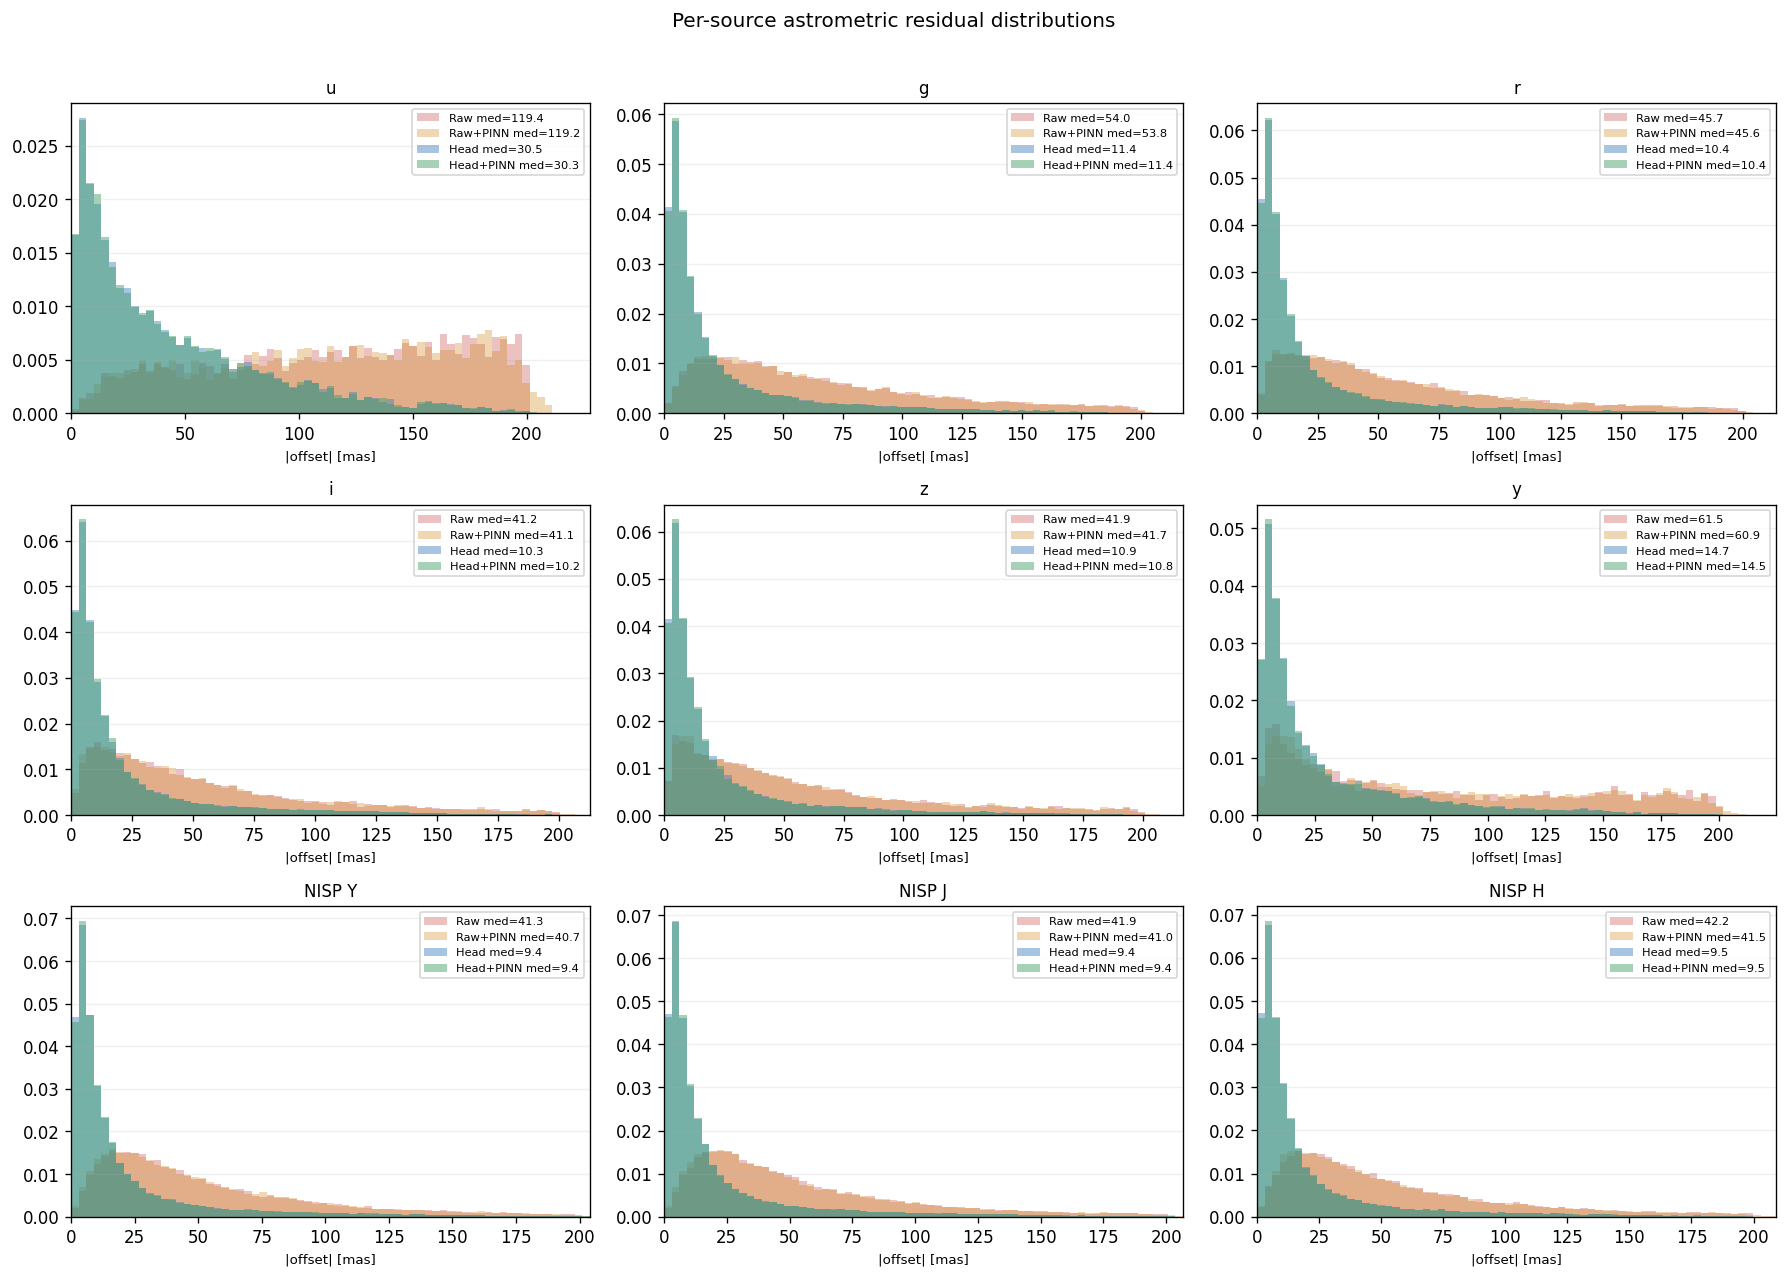

In [4]:
# Per-band radial histograms.
fig, axes = plt.subplots(3, 3, figsize=(15, 10.5))
axes_flat = axes.ravel()
for idx, band in enumerate(bands_present):
    ax = axes_flat[idx]
    d = data[band]
    raw_mag = mag_mas(d["raw"])
    head_mag = mag_mas(d["head"])
    raw_pinn_mag = mag_mas(d["raw_pinn"]) if d["raw_pinn"] is not None else None
    head_pinn_mag = mag_mas(d["head_pinn"]) if d["head_pinn"] is not None else None
    finite_ref = raw_mag[np.isfinite(raw_mag)]
    xlim = float(np.nanpercentile(finite_ref, 98.5)) if finite_ref.size else 100.0
    xlim = max(50.0, min(240.0, xlim * 1.15))
    bins = np.linspace(0, xlim, 70)
    ax.hist(raw_mag, bins=bins, alpha=0.34, color="#c84b4b", density=True,
            label=f"Raw med={np.nanmedian(raw_mag):.1f}")
    if raw_pinn_mag is not None:
        ax.hist(raw_pinn_mag, bins=bins, alpha=0.34, color="#d18b20", density=True,
                label=f"Raw+PINN med={np.nanmedian(raw_pinn_mag):.1f}")
    ax.hist(head_mag, bins=bins, alpha=0.46, color="#3f7fbf", density=True,
            label=f"Head med={np.nanmedian(head_mag):.1f}")
    if head_pinn_mag is not None:
        ax.hist(head_pinn_mag, bins=bins, alpha=0.46, color="#3d9b63", density=True,
                label=f"Head+PINN med={np.nanmedian(head_pinn_mag):.1f}")
    ax.set_title(display_band(band), fontsize=10)
    ax.set_xlabel("|offset| [mas]", fontsize=8)
    ax.set_xlim(0, xlim)
    ax.legend(fontsize=6.8)
    ax.grid(axis="y", alpha=0.2)
for ax in axes_flat[len(bands_present):]:
    ax.axis("off")
plt.suptitle("Per-source astrometric residual distributions", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "astrometry_histograms.png", dpi=220, bbox_inches="tight")
plt.show()


In [5]:
# Decomposed statistics table: |sys|, med, p68, MADxy per stage.
columns = [("Raw", "raw"), ("Raw+PINN", "raw_pinn"), ("Head", "head"), ("Head+PINN", "head_pinn")]
print(f'{"Band":>8} {"N":>8}  ' + "  ".join(f"{name:^25s}" for name, _ in columns))
print(f'{"":>8} {"":>8}  ' + "  ".join(f'{"|sys|":>6} {"med":>6} {"p68":>6} {"MADxy":>6}' for _ in columns))
print("-" * 128)
for band in bands_present:
    pieces = []
    for _, key in columns:
        arr = data[band].get(key)
        if arr is None:
            pieces.append(f"{np.nan:6.1f} {np.nan:6.1f} {np.nan:6.1f} {np.nan:6.1f}")
            continue
        st = vector_stats(arr)
        madxy = 0.5 * (st["mad_ra"] + st["mad_de"])
        pieces.append(f'{st["sys"]:6.1f} {st["med"]:6.1f} {st["p68"]:6.1f} {madxy:6.1f}')
    print(f'{display_band(band):>8} {data[band]["n"]:8d}  ' + "  ".join(pieces))
print("\n|sys| = magnitude of median RA/Dec residual vector [mas]")
print("med/p68 = radial per-source residual magnitude [mas]")
print("MADxy = average robust 1D component scatter [mas]")


    Band        N             Raw                     Raw+PINN                     Head                     Head+PINN        
                    |sys|    med    p68  MADxy   |sys|    med    p68  MADxy   |sys|    med    p68  MADxy   |sys|    med    p68  MADxy
--------------------------------------------------------------------------------------------------------------------------------
       u    12347    10.2  119.4  150.9   94.8     7.2  119.2  150.1   94.3     0.4   30.5   53.3   21.5     0.2   30.3   53.3   21.5
       g    60148     3.8   54.0   81.0   44.0     0.7   53.8   80.8   44.0     0.5   11.4   22.3    9.4     0.2   11.4   22.3    9.4
       r    70022     3.7   45.7   71.3   36.9     0.3   45.6   70.9   37.0     0.6   10.4   19.8    8.7     0.1   10.4   19.7    8.7
       i    62232     4.5   41.2   64.3   32.7     0.8   41.1   64.4   32.9     0.6   10.3   18.9    8.4     0.1   10.2   18.8    8.5
       z    42980     3.6   41.9   66.6   33.3     1.1   41.7   66.6   33.1

## Part 2 -- Spatial field maps

Where on the sky is the offset concentrated, before and after the head?
Each row is one band; the four columns are:

1. **raw anchors** -- binned median `|offset|` from `anchors.npz`.
2. **PINN raw** -- smooth PINN field fit to those raw offsets.
3. **head-resid anchors** -- binned median of `_head_resid`, the
   per-source leftover after the head correction.
4. **PINN after head** -- smooth PINN field fit to the head residuals.

If the head absorbs the coherent component, the third column should look
like unstructured scatter and the fourth should be near-flat.


In [ ]:
# 9x4 field comparison grid. Uses the PINN-raw FITS WCS to project anchors into a common sky frame.
# Per-column robust vmax (98th/95th percentile across all bands in that column) so outliers in a single
# panel do not blow out the scale, and a single colorbar at the bottom of each column rather than
# per-axis colorbars (saves horizontal space, lets columns sit closer together).
# Columns 1 and 3 (PINN model fields) are *dimmed* with a semi-transparent overlay in regions where
# the local anchor density is below MIN_COUNT, to flag PINN extrapolation versus data-constrained values.
BIN_ARCSEC = 60.0
MIN_COUNT = 4
MAS = 1000.0

with fits.open(FITS_PINN_RAW) as hdul:
    img_hdr = next(h.header for h in hdul[1:] if h.data is not None and h.data.ndim == 2)
    img_shape = next(h.data for h in hdul[1:] if h.data is not None and h.data.ndim == 2).shape
wcs_out = WCS(img_hdr)
image_h_pix, image_w_pix = img_shape
bin_px = max(1, int(round(BIN_ARCSEC / float(img_hdr.get("DSTEP", 1.0)))))
x_edges = np.arange(0, image_w_pix + bin_px, bin_px)
y_edges = np.arange(0, image_h_pix + bin_px, bin_px)


def bin_anchors(band, field_arr):
    """Return (median_grid, count_grid, n_anchors). count_grid is a 2D array of anchor counts per cell."""
    ra = data[band]["ra"]
    dec = data[band]["dec"]
    px, py = wcs_out.all_world2pix(ra, dec, 0)
    mag = np.hypot(field_arr[:, 0], field_arr[:, 1]) * MAS
    med, _, _, _ = binned_statistic_2d(px, py, mag, statistic="median", bins=[x_edges, y_edges])
    cnt, _, _, _ = binned_statistic_2d(px, py, mag, statistic="count", bins=[x_edges, y_edges])
    med = np.where(cnt >= MIN_COUNT, med, np.nan)
    return np.ma.masked_invalid(med.T), cnt.T.astype(int), int(len(ra))


def load_fits_fields(fits_path):
    out = {}
    with fits.open(fits_path) as hdul:
        for hdu in hdul[1:]:
            if hdu.data is None or not hdu.name or "." not in hdu.name:
                continue
            prefix, field = hdu.name.upper().rsplit(".", 1)
            out.setdefault(prefix, {})[field] = np.asarray(hdu.data, dtype=float)
    return out


pinn_raw_maps = load_fits_fields(FITS_PINN_RAW)
pinn_head_maps = load_fits_fields(FITS_PINN_HEAD)

# --- Pre-pass: collect all panels and per-band count grids. ---
panels_per_band = {}     # {band: [arr_col0, arr_col1, arr_col2, arr_col3]}
count_per_band = {}      # {band: count_grid}  (same for raw and head_resid, same anchors)
n_anchors_per_band = {}
for band in bands_present:
    ext = fits_ext(band)
    raw_bin, raw_cnt, n_anch = bin_anchors(band, data[band]["raw"])
    head_bin, _, _           = bin_anchors(band, data[band]["head"])
    pinn_raw_mag = np.ma.masked_invalid(
        np.hypot(pinn_raw_maps[ext]["DRA"], pinn_raw_maps[ext]["DDE"]) * MAS
    )
    pinn_head_mag = np.ma.masked_invalid(
        np.hypot(pinn_head_maps[ext]["DRA"], pinn_head_maps[ext]["DDE"]) * MAS
    )
    panels_per_band[band] = [raw_bin, pinn_raw_mag, head_bin, pinn_head_mag]
    count_per_band[band] = raw_cnt
    n_anchors_per_band[band] = n_anch

PERCENTILES = [95.0, 98.0, 95.0, 98.0]   # raw and head-resid columns are noisier -> tighter percentile


def _nice_vmax(v: float) -> float:
    """Round v up to 1/2/5 x 10^k for a tidy colorbar limit."""
    import math
    if not np.isfinite(v) or v <= 0:
        return 20.0
    exp = math.floor(math.log10(v))
    base = 10.0 ** exp
    norm = v / base
    if   norm <= 1.0:  return 1.0  * base
    elif norm <= 2.0:  return 2.0  * base
    elif norm <= 5.0:  return 5.0  * base
    else:              return 10.0 * base


per_col_vmax = []
for col, p in enumerate(PERCENTILES):
    pooled = []
    for band in bands_present:
        arr = panels_per_band[band][col]
        flat = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
        flat = flat[np.isfinite(flat)]
        if flat.size:
            pooled.append(flat)
    if pooled:
        all_vals = np.concatenate(pooled)
        per_col_vmax.append(_nice_vmax(float(np.nanpercentile(all_vals, p))))
    else:
        per_col_vmax.append(20.0)
print(f"Per-column robust vmax (mas): "
      f"raw={per_col_vmax[0]:.0f}, PINN_raw={per_col_vmax[1]:.0f}, "
      f"head_resid={per_col_vmax[2]:.0f}, PINN_after_head={per_col_vmax[3]:.0f}")


def make_extrap_overlay(count_grid: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    """Build an RGBA overlay that is opaque white where count_grid < MIN_COUNT, transparent elsewhere.
    Renders 'unconstrained' PINN regions as washed-out, signalling extrapolation rather than measurement.
    """
    H, W = count_grid.shape
    rgba = np.zeros((H, W, 4), dtype=float)
    low = count_grid < MIN_COUNT
    rgba[..., 0:3] = 1.0           # white
    rgba[..., 3]   = low * alpha    # opaque only where data is sparse
    return rgba


cmap = mpl.colormaps["magma"].copy()
cmap.set_bad("#202020")
col_labels = ["raw anchors", "PINN raw", "head-resid anchors", "PINN after head"]

n_rows = len(bands_present)
fig, axes = plt.subplots(n_rows, 4, figsize=(11, 2.0 * n_rows), squeeze=False)

ims_per_col = [None, None, None, None]
for row, band in enumerate(bands_present):
    ext = fits_ext(band)
    raw_bin, pinn_raw_mag, head_bin, pinn_head_mag = panels_per_band[band]
    cnt_grid = count_per_band[band]
    panels = [
        (raw_bin,       [0, image_w_pix, 0, image_h_pix], False),
        (pinn_raw_mag,  None,                              True),   # overlay on PINN columns
        (head_bin,      [0, image_w_pix, 0, image_h_pix], False),
        (pinn_head_mag, None,                              True),
    ]
    for col, (arr, extent, dim_low_density) in enumerate(panels):
        ax = axes[row, col]
        kwargs = dict(cmap=cmap, vmin=0, vmax=per_col_vmax[col], interpolation="nearest")
        if extent is not None:
            kwargs["extent"] = extent
        im = ax.imshow(arr, **kwargs)
        ims_per_col[col] = im

        # Dim PINN-extrapolation regions on columns 1 and 3 using the count grid from columns 0 / 2.
        if dim_low_density:
            overlay = make_extrap_overlay(cnt_grid, alpha=0.55)
            ax.imshow(overlay, extent=[0, image_w_pix, 0, image_h_pix],
                      interpolation="nearest", zorder=2)

        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=9, pad=4)
        v = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
        v = v[np.isfinite(v)]
        med = np.nanmedian(v) if v.size else np.nan
        p95 = np.nanpercentile(v, 95) if v.size else np.nan
        extra = f"\n{n_anchors_per_band[band]} anch" if col == 0 else ""
        ax.text(
            0.03, 0.97, f"{ext}\nmed {med:.1f} | p95 {p95:.1f}{extra}",
            transform=ax.transAxes, va="top", ha="left", fontsize=6.8, color="white",
            bbox=dict(boxstyle="round,pad=0.22", facecolor="black", alpha=0.55, edgecolor="none"),
            zorder=4,
        )

# Tighten the layout: no per-axis colorbars, much smaller wspace.
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.06, top=0.96, hspace=0.04, wspace=0.04)

# One horizontal colorbar per column, anchored under the bottom row.
for col, im in enumerate(ims_per_col):
    if im is None:
        continue
    bbox_top = axes[-1, col].get_position()
    cbar_h = 0.014
    cbar_y = bbox_top.y0 - 0.030
    cax = fig.add_axes([bbox_top.x0, cbar_y, bbox_top.width, cbar_h])
    cb = fig.colorbar(im, cax=cax, orientation="horizontal")
    cb.set_label(f"|f| [mas]   (vmax={per_col_vmax[col]:.0f})", fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig.suptitle(
    f"raw anchors → PINN raw   |   head-resid anchors → PINN after head   "
    f"(bin = {BIN_ARCSEC:.0f}\")\n"
    f"Washed-out regions on PINN columns: < {MIN_COUNT} anchors per cell — values are model "
    f"extrapolation, not data-constrained.",
    fontsize=9.5, y=0.992,
)
plt.savefig(OUT_DIR / "concordance_3way.png", dpi=180, bbox_inches="tight")
plt.show()


## Part 3 -- Anchor population

A classical bright-only concordance workflow leans on high-SNR stars. How
many do we actually have per band and per tile? This section characterises
the anchor population so the SNR-stratified refits below are interpretable.

- Per-band SNR distributions (log-x).
- Spatial density by SNR tercile (which parts of the survey are
  anchor-rich for a given SNR cut).
- Per-tile counts of high-SNR anchors -- how many tiles would be
  anchor-poor in a classical workflow.


In [ ]:
# Per-band SNR distributions.
# Three vertical reference lines per panel:
#   - dashed (median SNR): just descriptive
#   - dotted (33rd, 66th percentiles): the per-band tercile cuts used by the Part 4 PINN refits
#   - solid red (SNR = 30): the absolute "classical bright" threshold used by Part 3b leverage
# Single figure-level legend at the bottom so the panels stay clean.

SNR_BRIGHT_LINE = 30.0   # matches SNR_BRIGHT in Part 3b and SNR_BRIGHT_ABS in cell 12

fig, axes = plt.subplots(3, 3, figsize=(14, 9))

handle_med = handle_terc = handle_bright = None

for ax, band in zip(axes.ravel(), bands_present):
    snr = data[band]["snr"]
    snr = snr[np.isfinite(snr) & (snr > 0)]
    if snr.size == 0:
        ax.text(0.5, 0.5, "no SNR", transform=ax.transAxes, ha="center")
        ax.set_title(display_band(band))
        continue
    bins = np.logspace(np.log10(max(snr.min(), 1.0)), np.log10(max(snr.max(), 10.0)), 60)
    ax.hist(snr, bins=bins, color="#3f7fbf", alpha=0.85)
    ax.set_xscale("log")
    ax.set_xlabel("SNR", fontsize=8)

    med = float(np.median(snr))
    p33, p66 = np.percentile(snr, [33.33, 66.67])
    n_bright = int((snr >= SNR_BRIGHT_LINE).sum())
    frac_bright = n_bright / snr.size * 100.0

    h_m = ax.axvline(med,  color="k",       lw=1.0, ls="--", label="median")
    h_t = ax.axvline(p33,  color="0.45",    lw=0.9, ls=":",  label="terciles (Part 4 slices)")
    ax.axvline(      p66,  color="0.45",    lw=0.9, ls=":")
    h_b = ax.axvline(SNR_BRIGHT_LINE, color="#c84b4b", lw=1.4, ls="-",
                     label=f"bright cut (SNR$\\geq${SNR_BRIGHT_LINE:.0f})")

    handle_med, handle_terc, handle_bright = h_m, h_t, h_b

    ax.set_title(
        f"{display_band(band)}  N={snr.size}\n"
        f"med={med:.0f}  terciles=[{p33:.0f},{p66:.0f}]  "
        f"bright$\\geq${SNR_BRIGHT_LINE:.0f}: {n_bright} ({frac_bright:.1f}%)",
        fontsize=9,
    )
    ax.grid(axis="y", alpha=0.2)

for ax in axes.ravel()[len(bands_present):]:
    ax.axis("off")

# Single figure-level legend at the bottom so all panels share it.
if handle_med is not None:
    fig.legend(
        [handle_med, handle_terc, handle_bright],
        [handle_med.get_label(), handle_terc.get_label(), handle_bright.get_label()],
        loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.015),
        frameon=True, fontsize=10,
    )

plt.suptitle("Per-band SNR distribution", y=1.005)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.savefig(OUT_DIR / "anchor_snr_distributions.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Spatial anchor density at three *absolute* SNR thresholds.
# Replaces the equal-size SNR-tercile panels (which by construction had ~equal N per panel,
# so all three looked the same density-wise) with absolute SNR cuts. The faint pool now
# carries many more anchors than the bright pool, and the colorbar contrast reflects that.
# All three panels share a single robust vmax (95th percentile across them) so a few hot hexes
# do not blow out the scale.

SNR_CUT_BRIGHT = 30.0
SNR_CUT_MID    = 10.0

band_for_map = "i" if "i" in data else bands_present[0]
d = data[band_for_map]
snr = d["snr"]
ra_all, dec_all = d["ra"], d["dec"]
good = np.isfinite(snr) & (snr > 0)
n_total = int(good.sum())

masks = [
    (f"faint (SNR<{SNR_CUT_MID:.0f})",
     good & (snr < SNR_CUT_MID),                                          "#8b1a1a"),
    (f"mid ({SNR_CUT_MID:.0f}$\\leq$SNR<{SNR_CUT_BRIGHT:.0f})",
     good & (snr >= SNR_CUT_MID) & (snr < SNR_CUT_BRIGHT),                "#d18b20"),
    (f"bright (SNR$\\geq${SNR_CUT_BRIGHT:.0f})",
     good & (snr >= SNR_CUT_BRIGHT),                                      "#1d6ecf"),
]

extent = [ra_all.min(), ra_all.max(), dec_all.min(), dec_all.max()]
GRIDSIZE = 45

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), sharex=True, sharey=True)

# Pass 1: draw the hexbin on each panel and remember the counts so we can pick a shared vmax.
hbs = []
panel_n = []
for ax, (name, mask, _color) in zip(axes, masks):
    n = int(mask.sum())
    panel_n.append(n)
    if n == 0:
        ax.text(0.5, 0.5, "empty", transform=ax.transAxes, ha="center")
        ax.set_title(f"{display_band(band_for_map)}  {name}  N=0", fontsize=10)
        hbs.append(None)
        continue
    hb = ax.hexbin(ra_all[mask], dec_all[mask], gridsize=GRIDSIZE,
                   cmap="magma", mincnt=1, extent=extent)
    hbs.append(hb)
    ax.set_xlabel("RA [deg]")
    ax.invert_xaxis()
axes[0].set_ylabel("Dec [deg]")

# Compute a shared, robust vmax from the union of all panel counts.
all_counts = np.concatenate([hb.get_array() for hb in hbs if hb is not None])
all_counts = all_counts[np.isfinite(all_counts) & (all_counts > 0)]
if all_counts.size:
    shared_vmax = float(np.percentile(all_counts, 95))
else:
    shared_vmax = 1.0
# Round to a tidy number.
import math as _m
if shared_vmax > 0:
    _exp = _m.floor(_m.log10(shared_vmax))
    _base = 10.0 ** _exp
    _norm = shared_vmax / _base
    shared_vmax = (1.0 if _norm <= 1 else 2.0 if _norm <= 2 else 5.0 if _norm <= 5 else 10.0) * _base

# Pass 2: apply the shared vmax, attach colorbar, write title with both N and median per-bin density.
for ax, (name, mask, _color), hb, n in zip(axes, masks, hbs, panel_n):
    if hb is None:
        continue
    hb.set_clim(0, shared_vmax)
    counts = hb.get_array()
    counts = counts[np.isfinite(counts) & (counts > 0)]
    med_density = float(np.median(counts)) if counts.size else 0.0
    frac = 100.0 * n / max(n_total, 1)
    ax.set_title(
        f"{display_band(band_for_map)}  {name}\n"
        f"N={n:,} ({frac:.0f}% of band)   median density = {med_density:.0f}/bin",
        fontsize=9.5,
    )
    plt.colorbar(hb, ax=ax, label="anchors / bin")

plt.suptitle(
    f"Spatial anchor density by absolute SNR cut ({display_band(band_for_map)})\n"
    f"Same colorbar across panels (vmax = 95th-percentile of all bins, "
    f"= {shared_vmax:.0f}). Bright pool is much sparser than faint.",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "anchor_density_by_snr.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nTotal anchors in {display_band(band_for_map)}: {n_total:,}")
print(f"  faint  (SNR < {SNR_CUT_MID:.0f}):                {panel_n[0]:>8,}  ({100*panel_n[0]/n_total:.1f}%)")
print(f"  mid    ({SNR_CUT_MID:.0f} ≤ SNR < {SNR_CUT_BRIGHT:.0f}):  {panel_n[1]:>8,}  ({100*panel_n[1]/n_total:.1f}%)")
print(f"  bright (SNR ≥ {SNR_CUT_BRIGHT:.0f}):              {panel_n[2]:>8,}  ({100*panel_n[2]/n_total:.1f}%)")
print(f"  faint:bright ratio = {panel_n[0]/max(panel_n[2],1):.1f}× more faint than bright")


In [ ]:
# Bright-anchor count distribution per arcmin² cell at the classical SNR cut.
# Switched from per-tile (variable tile sizes, not directly tied to field uncertainty) to
# per-arcmin² (the resolution element used by Part 3b's leverage figure and the existing
# 60" concordance map binning). The "zero" / "<5" statistics now describe the fraction of
# resolution elements where a classical bright-only concordance fit would be data-starved.

SNR_BRIGHT_ABS = 30.0
ARCMIN = 60.0   # arcsec; matches Part 3b and the BIN_ARCSEC of the concordance maps

# Common tangent-plane frame across all bands so cells line up.
ra_full = np.concatenate([data[b]["ra"] for b in bands_present])
dec_full = np.concatenate([data[b]["dec"] for b in bands_present])
RA0_c = float(np.median(ra_full))
DEC0_c = float(np.median(dec_full))
cosdec_c = np.cos(np.deg2rad(DEC0_c))


def _xy_arcsec(ra, dec):
    return (
        (np.asarray(ra) - RA0_c) * cosdec_c * 3600.0,
        (np.asarray(dec) - DEC0_c) * 3600.0,
    )


x_full, y_full = _xy_arcsec(ra_full, dec_full)
edges_x_c = np.arange(x_full.min() - 1.0, x_full.max() + 1.0 + ARCMIN, ARCMIN)
edges_y_c = np.arange(y_full.min() - 1.0, y_full.max() + 1.0 + ARCMIN, ARCMIN)
n_cells_total = (len(edges_x_c) - 1) * (len(edges_y_c) - 1)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, band in zip(axes.ravel(), bands_present):
    snr = data[band]["snr"]
    if snr.size == 0:
        ax.axis("off"); continue

    # Per-cell counts: bright (SNR >= 30) and total occupancy.
    x_all, y_all = _xy_arcsec(data[band]["ra"], data[band]["dec"])
    H_all, _, _ = np.histogram2d(x_all, y_all, bins=[edges_x_c, edges_y_c])
    bright_mask = np.isfinite(snr) & (snr > SNR_BRIGHT_ABS)
    if bright_mask.sum() == 0:
        ax.text(0.5, 0.5, "no bright anchors", transform=ax.transAxes, ha="center")
        ax.set_title(display_band(band))
        continue
    xb, yb = _xy_arcsec(data[band]["ra"][bright_mask], data[band]["dec"][bright_mask])
    H_bright, _, _ = np.histogram2d(xb, yb, bins=[edges_x_c, edges_y_c])

    # Restrict the per-cell distribution to "occupied" cells (any anchor present).
    # A cell that is empty for all SNRs is outside the survey footprint or in a chip gap;
    # counting it as "zero bright" would conflate footprint with workflow weakness.
    occ = (H_all.ravel() > 0)
    bright_per_cell_occ = H_bright.ravel()[occ].astype(int)
    n_occ = int(occ.sum())

    # Histogram on integer bins.
    if bright_per_cell_occ.max() == 0:
        bins = np.arange(0, 3)
    else:
        bins = np.arange(0, max(int(bright_per_cell_occ.max()) + 2, 12))
    ax.hist(bright_per_cell_occ, bins=bins, color="#3d9b63", alpha=0.85)

    med = int(np.median(bright_per_cell_occ))
    n_zero = int((bright_per_cell_occ == 0).sum())
    n_poor = int((bright_per_cell_occ < 5).sum())
    ax.set_title(
        f"{display_band(band)}  occupied cells = {n_occ}\n"
        f"med = {med}/cell    zero-bright = {n_zero} ({100*n_zero/n_occ:.0f}%)    "
        f"<5-bright = {n_poor} ({100*n_poor/n_occ:.0f}%)",
        fontsize=9,
    )
    ax.set_xlabel(f"bright (SNR>{SNR_BRIGHT_ABS:.0f}) anchors per arcmin² cell", fontsize=8)
    ax.grid(axis="y", alpha=0.2)

for ax in axes.ravel()[len(bands_present):]:
    ax.axis("off")

plt.suptitle(
    f"Bright-anchor count per arcmin² cell (SNR > {SNR_BRIGHT_ABS:.0f})\n"
    f"{n_cells_total} total cells in mosaic; histogram restricted to occupied cells "
    f"(at least one anchor of any SNR present)",
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "bright_anchors_per_arcmin2.png", dpi=180, bbox_inches="tight")
plt.show()


## Part 3b -- Anchor leverage and per-source precision

Two headline numbers behind the case for a head-enabled concordance fit:

1. **Anchor density gain (per arcmin²).** A classical bright-only workflow (SNR$\geq$30)
   discards most of the catalogue. The head treats all detected sources as anchors. We bin
   anchors on a 1 arcmin × 1 arcmin grid -- the same 60" scale the existing concordance field
   maps use -- because that is the natural correlation-length scale for a smooth WCS distortion
   field. The figure shows per-band the median anchor density per cell at the two thresholds
   and the cell-coverage curve (fraction of occupied cells with $\geq$ N anchors). The
   per-cell density, not the per-tile count, is what drives the smooth-field uncertainty:
   `σ_field ∝ σ_anchor / √(anchors per resolution element)`.
2. **Per-source precision floor.** MADxy of the raw (PSF-fit centroid) offset and of the
   `head_resid` per source. The ratio is the precision improvement factor that the head
   buys at the source level. The right panel shows `|offset|` vs SNR for one band: the raw
   classical scatter follows the King floor $\propto 1/\mathrm{SNR}$, the head residual is
   much flatter -- the head decouples per-source precision from photometric SNR.

Together these say: **density per resolution element goes up by an order of magnitude and
per-source noise goes down by several×.** The smooth-field fit's statistical leverage is
$N_\mathrm{cell} \times \sigma^{-2}$, so this is roughly two orders of magnitude more
constraint per resolution element -- which is what should let us recover concordance in
fields where bright stars alone fail.


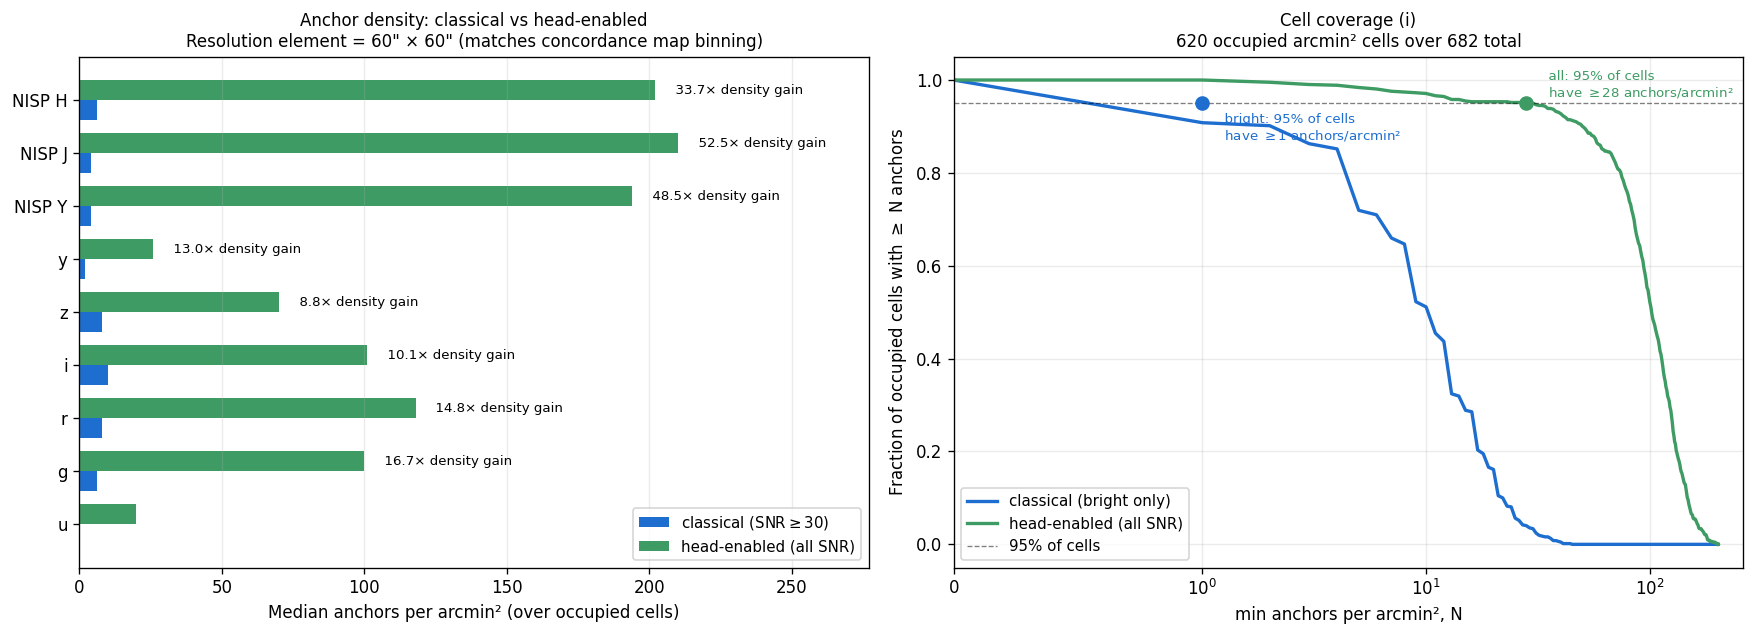


Resolution element: 60" × 60" = 1 arcmin² (matches concordance field-map bin)
Total cells in mosaic: 682

Per-band density (anchors / arcmin², median across occupied cells):
    Band     bright        all     × gain      N total
       u        0.0       20.0 20000000.0×       12,347
       g        6.0      100.0       16.7×       60,148
       r        8.0      118.0       14.8×       70,022
       i       10.0      101.0       10.1×       62,232
       z        8.0       70.0        8.8×       42,980
       y        2.0       26.0       13.0×       17,126
  NISP Y        4.0      194.0       48.5×      116,572
  NISP J        4.0      210.0       52.5×      126,352
  NISP H        6.0      202.0       33.7×      122,341


In [10]:
# === Anchor leverage: classical bright-only pool vs head-enabled pool, per arcmin^2 ===
# We bin anchors on a 1 arcmin x 1 arcmin grid in tangent-plane sky coordinates -- the same
# 60" scale used by the existing concordance field maps (BIN_ARCSEC=60 in Part 2). This is
# the natural correlation-length scale for a smooth WCS distortion field at survey level:
# anything finer than ~1' is below the WCS polynomial order, anything coarser washes out the
# coherent field structure. We then ask, per band, what the median per-cell anchor density is
# at each of two definitions, and what fraction of cells satisfies a minimum-N threshold:
#   - classical workflow: SNR >= SNR_BRIGHT (well-detected stars only)
#   - head-enabled: any anchor with finite, positive SNR

SNR_BRIGHT = 30.0
ARCMIN = 60.0  # arcsec; the resolution element (1 arcmin x 1 arcmin)

# Common tangent-plane frame across all bands so the per-band cells line up exactly.
ra_full = np.concatenate([data[b]["ra"] for b in bands_present])
dec_full = np.concatenate([data[b]["dec"] for b in bands_present])
RA0_lev = float(np.median(ra_full))
DEC0_lev = float(np.median(dec_full))
cosdec = np.cos(np.deg2rad(DEC0_lev))


def _to_arcsec_xy(ra, dec):
    x = (np.asarray(ra) - RA0_lev) * cosdec * 3600.0
    y = (np.asarray(dec) - DEC0_lev) * 3600.0
    return x, y


x_full, y_full = _to_arcsec_xy(ra_full, dec_full)
x_lo, x_hi = float(x_full.min()) - 1.0, float(x_full.max()) + 1.0
y_lo, y_hi = float(y_full.min()) - 1.0, float(y_full.max()) + 1.0
edges_x = np.arange(x_lo, x_hi + ARCMIN, ARCMIN)
edges_y = np.arange(y_lo, y_hi + ARCMIN, ARCMIN)
n_cells_total = (len(edges_x) - 1) * (len(edges_y) - 1)


def _counts_per_cell(ra, dec, mask=None):
    x, y = _to_arcsec_xy(ra, dec)
    if mask is not None:
        x = x[mask]; y = y[mask]
    if x.size == 0:
        return np.zeros((len(edges_y) - 1, len(edges_x) - 1), dtype=int)
    H, _, _ = np.histogram2d(y, x, bins=[edges_y, edges_x])
    return H.astype(int)


# Per-band per-cell counts at both thresholds.
table_lev = []
counts_per_band = {}   # {band: (counts_bright_grid, counts_all_grid)}
for band in bands_present:
    d = data[band]
    snr = d["snr"]
    good = np.isfinite(snr) & (snr > 0)
    n_total = int(good.sum())
    n_bright = int((good & (snr >= SNR_BRIGHT)).sum())
    n_mid = int((good & (snr >= 5.0) & (snr < SNR_BRIGHT)).sum())
    n_faint = int((good & (snr < 5.0)).sum())
    grid_bright = _counts_per_cell(d["ra"], d["dec"], good & (snr >= SNR_BRIGHT))
    grid_all    = _counts_per_cell(d["ra"], d["dec"], good)
    table_lev.append((band, n_total, n_bright, n_mid, n_faint))
    counts_per_band[band] = (grid_bright, grid_all)

bands_l = [r[0] for r in table_lev]
totals  = np.array([r[1] for r in table_lev])
brights = np.array([r[2] for r in table_lev])
mids    = np.array([r[3] for r in table_lev])
faints  = np.array([r[4] for r in table_lev])


def _median_density(grid, occupancy):
    occ = grid[occupancy]
    return float(np.median(occ)) if occ.size else 0.0


med_density_bright = []
med_density_all = []
occupied_cells_per_band = []
for band in bands_l:
    g_b, g_a = counts_per_band[band]
    occupancy = g_a > 0
    occupied_cells_per_band.append(int(occupancy.sum()))
    med_density_bright.append(_median_density(g_b, occupancy))
    med_density_all.append(_median_density(g_a, occupancy))
med_density_bright = np.array(med_density_bright)
med_density_all = np.array(med_density_all)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

# Panel 1: per-band median anchor density per arcmin^2, classical vs head-enabled.
ax = axes[0]
y = np.arange(len(bands_l))
wbar = 0.38
ax.barh(y - wbar/2, med_density_bright, wbar, color="#1d6ecf",
        label=f"classical (SNR$\\geq${SNR_BRIGHT:.0f})")
ax.barh(y + wbar/2, med_density_all,    wbar, color="#3d9b63",
        label="head-enabled (all SNR)")
xmax = float(med_density_all.max())
for i, (b_, a_) in enumerate(zip(med_density_bright, med_density_all)):
    if b_ > 0:
        ratio = a_ / b_
        ax.text(a_ + 0.02 * xmax, i + wbar/2, f"  {ratio:.1f}× density gain",
                va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels([display_band(b) for b in bands_l])
ax.set_xlabel("Median anchors per arcmin² (over occupied cells)")
ax.set_title(f"Anchor density: classical vs head-enabled\n"
             f"Resolution element = {ARCMIN:.0f}\" × {ARCMIN:.0f}\" "
             f"(matches concordance map binning)", fontsize=10)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.25)
ax.set_xlim(0, xmax * 1.32)

# Panel 2: cell-coverage curves -- fraction of cells with at least N anchors at each threshold,
# for one representative band. This is the per-resolution-element analogue of the per-tile coverage
# curve, and is the right metric for a smooth-field fit (anchors per resolution element drive the
# field uncertainty, not anchors per tile).
ax = axes[1]
band_for_cov = "i" if "i" in data else bands_present[0]
g_b, g_a = counts_per_band[band_for_cov]
occupied = (g_a > 0)
n_occ = int(occupied.sum())
counts_bright_flat = g_b[occupied]
counts_all_flat    = g_a[occupied]
n_max = max(int(counts_all_flat.max()) if n_occ else 1, 2)
N_axis = np.arange(0, n_max + 2)
frac_bright = np.array([(counts_bright_flat >= n).sum() / max(n_occ, 1) for n in N_axis])
frac_all    = np.array([(counts_all_flat    >= n).sum() / max(n_occ, 1) for n in N_axis])
ax.plot(N_axis, frac_bright, color="#1d6ecf", lw=2, label="classical (bright only)")
ax.plot(N_axis, frac_all,    color="#3d9b63", lw=2, label="head-enabled (all SNR)")
ax.axhline(0.95, color="k", ls="--", lw=0.8, alpha=0.5, label="95% of cells")


def _N_at_frac(N_axis, frac, target=0.95):
    if frac.max() < target:
        return None
    return int(N_axis[np.searchsorted(-frac, -target)])


n95_bright = _N_at_frac(N_axis, frac_bright, 0.95)
n95_all    = _N_at_frac(N_axis, frac_all, 0.95)
if n95_bright is not None:
    ax.scatter([n95_bright], [0.95], color="#1d6ecf", s=60, zorder=5)
    ax.annotate(f"  bright: 95% of cells\n  have $\\geq${n95_bright} anchors/arcmin²",
                (n95_bright, 0.95), xytext=(8, -22), textcoords="offset points",
                fontsize=8, color="#1d6ecf")
if n95_all is not None:
    ax.scatter([n95_all], [0.95], color="#3d9b63", s=60, zorder=5)
    ax.annotate(f"  all: 95% of cells\n  have $\\geq${n95_all} anchors/arcmin²",
                (n95_all, 0.95), xytext=(8, 4), textcoords="offset points",
                fontsize=8, color="#3d9b63")
ax.set_xscale("symlog", linthresh=1)
ax.set_xlim(0, n_max * 1.3)
ax.set_xlabel("min anchors per arcmin², N")
ax.set_ylabel("Fraction of occupied cells with $\\geq$ N anchors")
ax.set_title(f"Cell coverage ({display_band(band_for_cov)})\n"
             f"{n_occ} occupied arcmin² cells over {n_cells_total} total",
             fontsize=10)
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.savefig(OUT_DIR / "anchor_leverage_gain.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nResolution element: {ARCMIN:.0f}\" × {ARCMIN:.0f}\" = 1 arcmin² "
      f"(matches concordance field-map bin)")
print(f"Total cells in mosaic: {n_cells_total}\n")
print("Per-band density (anchors / arcmin², median across occupied cells):")
print(f'{"Band":>8} {"bright":>10} {"all":>10} {"× gain":>10} {"N total":>12}')
for i, b in enumerate(bands_l):
    g = med_density_all[i] / max(med_density_bright[i], 1e-6)
    print(f"{display_band(b):>8} {med_density_bright[i]:10.1f} {med_density_all[i]:10.1f} "
          f"{g:10.1f}× {totals[i]:12,}")


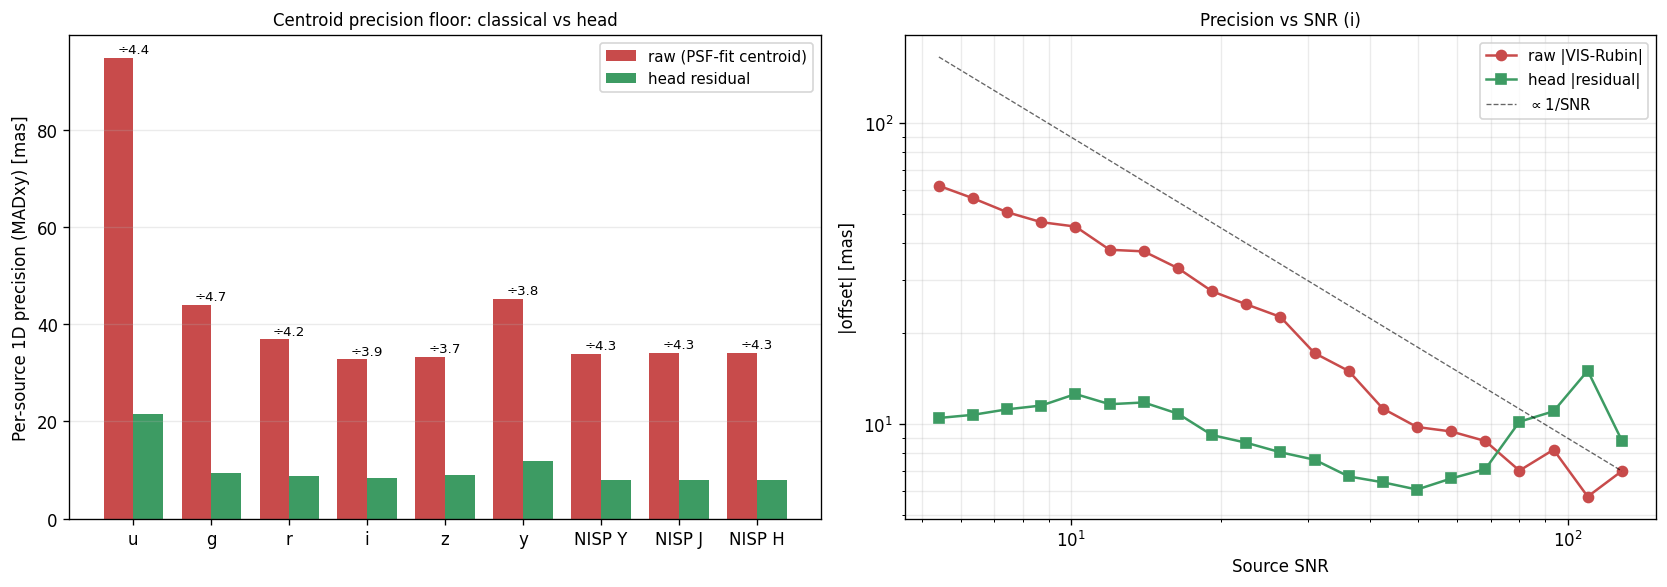


Per-band precision floor (MADxy in mas):
    Band        raw       head     factor
       u       94.8       21.5        4.4×
       g       44.0        9.4        4.7×
       r       36.9        8.7        4.2×
       i       32.7        8.4        3.9×
       z       33.3        8.9        3.7×
       y       45.2       11.8        3.8×
  NISP Y       33.9        7.8        4.3×
  NISP J       34.1        7.9        4.3×
  NISP H       34.2        7.9        4.3×


In [11]:
# === Per-source precision: how much sharper is the head than classical PSF-fit centroiding? ===
# Use MADxy as an empirical per-source precision floor:
#   - on raw (= classical PSF-fit centroid VIS-vs-band offset): includes WCS field + per-source noise.
#   - on head_resid (= leftover after the head correction): per-source noise after the head removed
#     both the smooth field and the per-source bias. The robust scatter MADxy is dominated by
#     centroid noise, so the ratio raw/head is the precision improvement factor.
# We also show how each scales with SNR for one band: classical centroids should track ~1/SNR
# (PSF-width / SNR), the head should be much flatter if it is band+SNR-aware.

prec_rows = []
for band in bands_present:
    d = data[band]
    raw_madxy  = 0.5 * (mad_sigma(d["raw"][:, 0])  + mad_sigma(d["raw"][:, 1]))  * 1000.0   # mas
    head_madxy = 0.5 * (mad_sigma(d["head"][:, 0]) + mad_sigma(d["head"][:, 1])) * 1000.0
    prec_rows.append((band, raw_madxy, head_madxy))

bands_p = [r[0] for r in prec_rows]
raw_madxy_arr  = np.array([r[1] for r in prec_rows])
head_madxy_arr = np.array([r[2] for r in prec_rows])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: per-band paired bars with ratio annotation.
ax = axes[0]
xp = np.arange(len(bands_p))
wbar = 0.38
ax.bar(xp - wbar/2, raw_madxy_arr,  wbar, color="#c84b4b", label="raw (PSF-fit centroid)")
ax.bar(xp + wbar/2, head_madxy_arr, wbar, color="#3d9b63", label="head residual")
for i, (rv, hv) in enumerate(zip(raw_madxy_arr, head_madxy_arr)):
    if hv > 0:
        ax.text(xp[i], max(rv, hv) + 1.0, f"÷{rv/hv:.1f}", ha="center", fontsize=8)
ax.set_xticks(xp)
ax.set_xticklabels([display_band(b) for b in bands_p])
ax.set_ylabel("Per-source 1D precision (MADxy) [mas]")
ax.set_title("Centroid precision floor: classical vs head", fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)

# Panel 2: precision vs SNR for one representative band.
ax = axes[1]
band_for_snr = "i" if "i" in data else bands_present[0]
d = data[band_for_snr]
snr = d["snr"]
mag_raw  = mag_mas(d["raw"])
mag_head = mag_mas(d["head"])
ok = np.isfinite(snr) & (snr > 0)
snr_ok = snr[ok]; raw_ok = mag_raw[ok]; head_ok = mag_head[ok]
bins_snr = np.logspace(np.log10(max(snr_ok.min(), 3.0)), np.log10(snr_ok.max()), 22)
mid_b = np.sqrt(bins_snr[:-1] * bins_snr[1:])

def _running_med(y, x, edges):
    out = np.full(len(edges) - 1, np.nan)
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (x >= lo) & (x < hi)
        if m.sum() > 5:
            out[i] = np.median(y[m])
    return out

med_raw  = _running_med(raw_ok,  snr_ok, bins_snr)
med_head = _running_med(head_ok, snr_ok, bins_snr)
ax.plot(mid_b, med_raw,  "o-", color="#c84b4b", label="raw |VIS-Rubin|")
ax.plot(mid_b, med_head, "s-", color="#3d9b63", label="head |residual|")
# Reference 1/SNR line, anchored to the brightest raw point.
finite_mask = np.isfinite(med_raw)
if finite_mask.any():
    fb = mid_b[finite_mask]
    fy = med_raw[finite_mask]
    j = int(np.argmax(fb))
    ref_y = fy[j] * fb[j] / mid_b
    ax.plot(mid_b, ref_y, "k--", lw=0.8, alpha=0.6, label=r"$\propto 1/\mathrm{SNR}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Source SNR"); ax.set_ylabel("|offset| [mas]")
ax.set_title(f"Precision vs SNR ({display_band(band_for_snr)})", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.savefig(OUT_DIR / "per_source_precision.png", dpi=180, bbox_inches="tight")
plt.show()

print("\nPer-band precision floor (MADxy in mas):")
print(f'{"Band":>8} {"raw":>10} {"head":>10} {"factor":>10}')
for b, rv, hv in prec_rows:
    print(f"{display_band(b):>8} {rv:10.1f} {hv:10.1f} {rv/max(hv,1e-6):10.1f}×")


## Part 4 -- SNR-stratified PINN refits

The main experiment. For each SNR slice (per-band tercile: top / middle /
bottom third) we refit the PINN jointly across all 9 bands, and we do it
twice:

- **on raw anchors** (`{band}_raw`): the measured band-to-VIS offsets (Rubin ugrizy or NISP YJH, each compared against Euclid VIS).
  Amplitude of the fitted field reflects the smooth concordance signal
  plus centroid noise. Bright-only should be signal-dominated; faint-only
  should be noise-dominated (the field is too small to see through King
  FWHM/SNR scatter).
- **on head-residual anchors** (`{band}_head_resid`): what is left per
  source after the head. A small amplitude across all slices means the
  head has absorbed the coherent component independent of source SNR.

Each refit uses 4000 Adam steps and 8000 collocation points -- lighter
than the production settings so the notebook finishes in a few minutes
on GPU while staying within a mas or two of the converged field.


In [ ]:
# Build per-slice anchor tables, then fit PINN jointly across bands.
N_STEPS_REFIT = 4000
N_COLLOC_REFIT = 8000

# Common tangent-plane frame: compute ra0/dec0 from all anchors so every refit shares axes.
ra_all = np.concatenate([data[b]["ra"] for b in bands_present])
dec_all = np.concatenate([data[b]["dec"] for b in bands_present])
pos_all, RA0, DEC0 = sky_to_tangent_plane(ra_all, dec_all)
POS_MIN = pos_all.min(axis=0).astype(np.float32)
POS_MAX = pos_all.max(axis=0).astype(np.float32)
FIELD_W = int(np.ceil(float(POS_MAX[0] - POS_MIN[0]))) + 2
FIELD_H = int(np.ceil(float(POS_MAX[1] - POS_MIN[1]))) + 2
print(f"Common tangent frame: RA0={RA0:.4f} DEC0={DEC0:.4f}")
print(f"Field size (arcsec): {FIELD_W} x {FIELD_H}")


def tangent_shifted(ra, dec):
    cosdec = np.cos(np.deg2rad(DEC0))
    x = (np.asarray(ra) - RA0) * cosdec * 3600.0
    y = (np.asarray(dec) - DEC0) * 3600.0
    pos = np.stack([x, y], axis=1).astype(np.float32)
    return (pos - POS_MIN[None, :]).astype(np.float32)


def build_slice(snr_mode: str, offset_key: str) -> dict:
    """snr_mode in {'all','bright','mid','faint'}; offset_key in {'raw','head_resid'}.

    Returns dict with pos, offsets, weights, band_idx, n_per_band.
    """
    pos_list, off_list, w_list, bi_list, nper = [], [], [], [], {}
    for band in bands_present:
        d = data[band]
        snr = d["snr"]
        off = d["raw"] if offset_key == "raw" else d["head"]
        good = np.isfinite(snr) & (snr > 0)
        if good.sum() < 30:
            continue
        if snr_mode == "all":
            sel = good
        else:
            lo, hi = np.percentile(snr[good], [33.33, 66.67])
            if snr_mode == "bright":
                sel = good & (snr >= hi)
            elif snr_mode == "mid":
                sel = good & (snr >= lo) & (snr < hi)
            elif snr_mode == "faint":
                sel = good & (snr < lo)
            else:
                raise ValueError(snr_mode)
        pos = tangent_shifted(d["ra"][sel], d["dec"][sel])
        pos_list.append(pos)
        off_list.append(off[sel])
        # Weight ~ SNR^2 (King-scaling). Floor so per-slice weights aren't pathological.
        snr_s = np.clip(snr[sel], 3.0, None)
        w_list.append((snr_s ** 2).astype(np.float32))
        bi_list.append(np.full(int(sel.sum()), BAND_TO_IDX[band], dtype=np.int64))
        nper[band] = int(sel.sum())
    if not pos_list:
        return None
    return {
        "pos": np.concatenate(pos_list, axis=0),
        "offsets": np.concatenate(off_list, axis=0).astype(np.float32),
        "weights": np.concatenate(w_list, axis=0),
        "band_idx": np.concatenate(bi_list, axis=0),
        "n_per_band": nper,
    }


def fit_slice(slice_tab, tag):
    print(f"\n=== Fit {tag}  (N={len(slice_tab['pos'])}, bands={len(slice_tab['n_per_band'])}) ===")
    t0 = time.time()
    model, meta = fit_pinn_field(
        pos_arcsec=slice_tab["pos"],
        offsets_arcsec=slice_tab["offsets"],
        weights=slice_tab["weights"],
        band_indices=slice_tab["band_idx"],
        n_bands=N_BANDS,
        hidden_dim=128,
        n_layers=5,
        n_steps=N_STEPS_REFIT,
        lr=1e-3,
        lambda_curl=1.0,
        lambda_lapl=0.1,
        lambda_band=0.1,
        n_collocation=N_COLLOC_REFIT,
        device=DEVICE,
        verbose=False,
    )
    print(f"  done in {time.time() - t0:.1f}s  best_loss={meta['best_loss']:.4g}")
    return model, meta


SLICES = ["all", "bright", "mid", "faint"]
KINDS = ["raw", "head_resid"]
fits_store: dict[tuple[str, str], dict] = {}
for kind in KINDS:
    for snr_mode in SLICES:
        tab = build_slice(snr_mode, kind)
        if tab is None:
            continue
        model, meta = fit_slice(tab, f"{snr_mode} / {kind}")
        fits_store[(snr_mode, kind)] = {
            "model": model, "meta": meta, "table": tab,
        }
print(f"\nCompleted {len(fits_store)} PINN refits")


Common tangent frame: RA0=53.0896 DEC0=-28.1259
Field size (arcsec): 1275 x 1829

=== Fit all / raw  (N=630120, bands=9) ===
  done in 438.2s  best_loss=0.06863

=== Fit bright / raw  (N=210020, bands=9) ===
  done in 169.8s  best_loss=0.07552

=== Fit mid / raw  (N=210083, bands=9) ===


In [ ]:
# Evaluate each fit on the common mesh (geometric field + per-band) and record amplitudes.
def eval_mesh(model, meta, band_idx_int=None):
    res = evaluate_pinn_mesh(
        model, meta, FIELD_H, FIELD_W, dstep=1,
        pos_arcsec_anchors=None, band_idx=band_idx_int,
    )
    return res


def field_rms_mas(res):
    dra = res["dra"] * 1000.0
    ddec = res["ddec"] * 1000.0
    return float(np.sqrt(np.nanmean(dra ** 2 + ddec ** 2)))


def field_p95_mas(res):
    mag = np.hypot(res["dra"], res["ddec"]) * 1000.0
    return float(np.nanpercentile(mag, 95))


summary_rows = []
for (snr_mode, kind), entry in fits_store.items():
    tab = entry["table"]
    # Residual at anchors.
    model = entry["model"]; meta = entry["meta"]
    pos_n = (tab["pos"] - meta["pos_min"]) / meta["pos_scale"] * 2.0 - 1.0
    with torch.no_grad():
        xy_t = torch.tensor(pos_n, dtype=torch.float32)
        bi_t = torch.tensor(tab["band_idx"], dtype=torch.long)
        pred = model(xy_t, band_idx=bi_t).numpy() * meta["off_scale"]
    resid = tab["offsets"] - pred
    # Geometric (achromatic) field on the mesh.
    geo = eval_mesh(model, meta, band_idx_int=None)
    summary_rows.append({
        "slice": snr_mode, "kind": kind,
        "N": int(tab["pos"].shape[0]),
        "raw_med_mas": float(med_mas(tab["offsets"])),
        "resid_med_mas": float(med_mas(resid)),
        "field_rms_mas": field_rms_mas(geo),
        "field_p95_mas": field_p95_mas(geo),
    })
    entry["geo"] = geo
    entry["resid"] = resid

summary_tab = Table(rows=[(r["slice"], r["kind"], r["N"],
                           f"{r['raw_med_mas']:.1f}",
                           f"{r['resid_med_mas']:.1f}",
                           f"{r['field_rms_mas']:.1f}",
                           f"{r['field_p95_mas']:.1f}")
                          for r in summary_rows],
                   names=["slice", "kind", "N", "raw_med",
                          "resid_med", "field_rms", "field_p95"])
display(summary_tab)


## Part 4b -- Bootstrap and shuffled-null tests: how much to trust the field

The Part 4 summary table prints a single field-RMS number per slice and per kind. Two questions
are not answered by that single number:

1. **What is the statistical uncertainty on the field RMS?** A point estimate of "5.2 mas" is
   meaningless without a 1σ_boot error bar -- if the bootstrap std is also 5 mas, the
   measurement is consistent with zero.
2. **What does the PINN do on data with no spatial coherence?** Even a pure-noise input,
   fed to a sufficiently flexible smoothness-regularised network, can produce a non-zero
   field. We need a noise floor: the field RMS the PINN extracts when we destroy the spatial
   structure by permuting positions. Real RMS / null RMS is the clean significance ratio.

The cell below runs both: a 3× bootstrap on each of the 8 slice/kind combinations, and one
shuffled-null refit per combination. Then plots the field RMS with error bars against
the null floor, per slice. A trustworthy fit sits well above its null floor with a small
fractional bootstrap σ. The head_resid slices should hug zero (and hug their null floors --
the head removed the smooth field, leaving nothing for the PINN to extract).

Settings are dialled down (1500 Adam steps, 4000 collocation points, 60k anchor cap) so the
whole block finishes in ~10-15 min on GPU. For a publication-quality run, increase `N_BOOT`
to ~10 and revert to `N_STEPS=4000`, `N_COLLOC=8000`.


In [ ]:
# === Trustworthiness diagnostics: bootstrap field RMS + shuffled null test ===
# Two complementary tests that the smooth field we fit is real signal, not noise the PINN absorbed.
#
#   (a) Bootstrap. Resample anchors with replacement, refit the PINN, record the field RMS.
#       Std across resamples = statistical uncertainty on the field measurement.
#   (b) Shuffled null. Permute anchor (RA,Dec) while keeping offsets, refit. The resulting
#       field is what the PINN extracts when there is no spatial coherence by construction.
#       Real RMS / null RMS = significance ratio. >>1 means real, ~1 means we are fitting noise.
#
# Both refits run at reduced settings (fewer Adam steps, fewer collocation points,
# subsampled anchor pool) so 8 slices x (3 bootstraps + 1 null) finish in roughly 10-15 min on GPU.
# Bump N_BOOT and revert to N_STEPS=4000 for a publication run.

import time as _time

N_BOOT = 3
N_STEPS_FAST = 1500
N_COLLOC_FAST = 4000
SUBSAMPLE_CAP = 60_000   # cap each refit at 60k anchors to keep wall time tractable
RNG = np.random.default_rng(0)


def _eval_field_rms(model, meta) -> float:
    res = evaluate_pinn_mesh(model, meta, FIELD_H, FIELD_W, dstep=1, band_idx=None)
    return float(np.sqrt(np.nanmean((res["dra"] * 1000.0) ** 2 + (res["ddec"] * 1000.0) ** 2)))


def _quick_fit(pos, off, w, bi):
    m, mt = fit_pinn_field(
        pos_arcsec=pos, offsets_arcsec=off, weights=w,
        band_indices=bi, n_bands=N_BANDS,
        n_steps=N_STEPS_FAST, n_collocation=N_COLLOC_FAST,
        device=DEVICE, verbose=False,
    )
    return _eval_field_rms(m, mt)


def _maybe_subsample(tab, cap):
    N = len(tab["pos"])
    if N <= cap:
        return tab
    idx = RNG.choice(N, size=cap, replace=False)
    return {
        "pos": tab["pos"][idx], "offsets": tab["offsets"][idx],
        "weights": tab["weights"][idx], "band_idx": tab["band_idx"][idx],
        "n_per_band": tab["n_per_band"],
    }


trust_rows = []
total_fits = sum(1 for _ in SLICES) * len(KINDS) * (N_BOOT + 1)
done = 0
for snr_mode in SLICES:
    for kind in KINDS:
        tab_full = build_slice(snr_mode, kind)
        if tab_full is None:
            continue
        tab = _maybe_subsample(tab_full, SUBSAMPLE_CAP)
        N = len(tab["pos"])

        # Bootstrap on real data.
        boot_real = []
        for b in range(N_BOOT):
            idx = RNG.integers(0, N, size=N)
            t0 = _time.time()
            rms = _quick_fit(tab["pos"][idx], tab["offsets"][idx], tab["weights"][idx], tab["band_idx"][idx])
            boot_real.append(rms)
            done += 1
            print(f"  [{done}/{total_fits}] boot {snr_mode}/{kind} #{b+1}/{N_BOOT}  RMS={rms:5.2f} mas  ({_time.time()-t0:.0f}s)")
        boot_real = np.array(boot_real)

        # Shuffled null: permute positions only.
        perm = RNG.permutation(N)
        t0 = _time.time()
        rms_null = _quick_fit(tab["pos"][perm], tab["offsets"], tab["weights"], tab["band_idx"])
        done += 1
        print(f"  [{done}/{total_fits}] null {snr_mode}/{kind}              RMS={rms_null:5.2f} mas  ({_time.time()-t0:.0f}s)")

        trust_rows.append({
            "slice": snr_mode, "kind": kind, "N_used": N, "N_full": len(tab_full["pos"]),
            "rms_mean": float(boot_real.mean()),
            "rms_std":  float(boot_real.std(ddof=1)) if N_BOOT > 1 else 0.0,
            "rms_null": float(rms_null),
            "snr_significance": float(boot_real.mean() / max(rms_null, 1e-6)),
        })

trust_tab = Table(rows=[(r["slice"], r["kind"], r["N_used"], r["N_full"],
                          f"{r['rms_mean']:.2f}±{r['rms_std']:.2f}",
                          f"{r['rms_null']:.2f}",
                          f"{r['snr_significance']:.1f}×")
                          for r in trust_rows],
                  names=["slice", "kind", "N_used", "N_full", "field RMS [mas]",
                         "null RMS [mas]", "signal/null"])
display(trust_tab)


In [ ]:
# Plot: bootstrap field RMS vs shuffled-null floor, by SNR slice and kind.
# Squares = head_resid kind, circles = raw kind. X-axis = anchors used in fit (subsample-capped).
# Real-signal points carry vertical 1σ_boot bars; null points are crosses.
# A point well above its corresponding null cross = significant smooth-field detection at that slice.

fig, ax = plt.subplots(figsize=(9.5, 5.5))
kind_style = {"raw": ("o", "#c84b4b"), "head_resid": ("s", "#3f7fbf")}
seen_labels = set()
for r in trust_rows:
    marker, color = kind_style[r["kind"]]
    label_real = f"{r['kind']} field RMS"
    label_null = f"{r['kind']} shuffled null"
    ax.errorbar(
        [r["N_used"]], [r["rms_mean"]], yerr=[r["rms_std"]],
        fmt=marker, ms=10, color=color, ecolor=color, elinewidth=1.4, capsize=4,
        markeredgecolor="k", markeredgewidth=0.6,
        label=label_real if label_real not in seen_labels else None,
    )
    seen_labels.add(label_real)
    ax.scatter([r["N_used"]], [r["rms_null"]], marker="x", s=70, color=color, alpha=0.55,
               label=label_null if label_null not in seen_labels else None)
    seen_labels.add(label_null)
    ax.annotate(r["slice"], (r["N_used"], r["rms_mean"]),
                xytext=(7, 6), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Anchors in fit (subsample-capped)", fontsize=10)
ax.set_ylabel("Field RMS [mas]", fontsize=10)
ax.set_title(f"Field amplitude with bootstrap error bars vs shuffled-null floor "
             f"(N_boot={N_BOOT}, n_steps={N_STEPS_FAST})", fontsize=10)
ax.legend(fontsize=8.5, loc="upper right", ncol=2)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(OUT_DIR / "snr_field_amp_with_null.png", dpi=180, bbox_inches="tight")
plt.show()

# Compact significance summary, by kind. Tells you whether the real-data field beats the null.
print("\nSignal/null ratios (median across slices):")
for kind in KINDS:
    rows_k = [r for r in trust_rows if r["kind"] == kind]
    if not rows_k:
        continue
    sig = np.array([r["snr_significance"] for r in rows_k])
    print(f"  {kind:>10}  signal/null  min={sig.min():.1f}×  med={np.median(sig):.1f}×  max={sig.max():.1f}×")
print("\nInterpretation:")
print("  - real >> null  : the smooth field is a genuine spatial signal in this slice/kind.")
print("  - real ≈ null   : the PINN is fitting noise; the apparent field is not trustworthy.")
print("  - The head_resid columns should sit close to zero AND close to the null -- the head")
print("    has already removed the coherent component, so there is little smooth field left to fit.")


## Part 4c -- Gaussian Process cross-check on the smooth field

The PINN is one way to fit a smooth field; its uncertainty has to be estimated by bootstrap
because the smoothness is set by curl/Laplacian regulariser weights, not by an interpretable
kernel. A Gaussian Process with an explicit kernel (RBF + white noise) gives a calibrated
posterior over the field out of the box, and serves as an independent cross-check on the
PINN's geometric field.

The cell below:

1. Subsamples ~1500 anchors from the **bright/raw** slice (the classical-concordance setting
   where we expect the cleanest signal) and fits two independent scalar GPs on $\Delta\mathrm{RA}^*$
   and $\Delta\mathrm{Dec}$, with a Matern-style RBF kernel whose length scale is fit to the data.
2. Evaluates the GP mean field on the same mesh as the PINN, and compares: GP map, PINN map,
   GP $-$ PINN difference. Agreement to within a couple of mas means the smooth field is
   real and the PINN is not a regulariser artefact.
3. Holds out 20% of anchors for a **calibration check**: the GP-predicted residual divided by
   the GP standard deviation should be a unit normal. $\mathrm{std}(z) \approx 1$ means the
   GP error bars are honest. $\mathrm{std}(z) > 1$ means it is overconfident (kernel too rigid),
   $< 1$ means underconfident (kernel too loose).

The GP also reports its **fit length scale**, which is the data-preferred correlation length
of the field. If that comes out near 60" we have a self-consistency check on the choice of
arcmin² as the resolution element. If it is much larger (~degree scale), the field is dominated
by full-FOV WCS distortion; if much smaller, the PINN's smoothness regulariser is probably
oversmoothing.


In [ ]:
# === Part 4c: GP cross-check on the bright/raw slice ===
# Independent measurement of the smooth field using a Gaussian Process with an interpretable
# kernel and calibrated posterior. We compare the GP mean to the PINN map (regulariser-vs-kernel
# cross-check), and report a held-out z-score histogram (calibration check).
#
# Subsample to 1500 anchors so sklearn's exact GP (O(N^3) Cholesky) is tractable; this is plenty
# for a smooth low-order field and matches the bandwidth ~60" we expect.

try:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import ConstantKernel as _C, RBF, WhiteKernel
    _HAVE_SK = True
except ImportError:
    _HAVE_SK = False
    print("sklearn not available; skipping GP cross-check")

if _HAVE_SK:
    import time as _time

    GP_SLICE, GP_KIND = "bright", "raw"
    N_GP = 1500
    MESH_STRIDE = 4   # downsample mesh for speed; GP mean is smooth enough that stride=4 is fine
    HOLDOUT_FRAC = 0.20

    if (GP_SLICE, GP_KIND) not in fits_store:
        print(f"PINN fit for {GP_SLICE}/{GP_KIND} not in fits_store -- run Part 4 first")
    else:
        tab_gp = build_slice(GP_SLICE, GP_KIND)
        rng = np.random.default_rng(42)
        idx_sub = rng.choice(len(tab_gp["pos"]), size=min(N_GP, len(tab_gp["pos"])), replace=False)
        pos_sub = tab_gp["pos"][idx_sub].astype(np.float64)         # tangent xy in arcsec
        off_sub = tab_gp["offsets"][idx_sub].astype(np.float64)     # arcsec

        # Hold-out split for calibration.
        n_hold = int(HOLDOUT_FRAC * len(idx_sub))
        hold_mask = np.zeros(len(idx_sub), dtype=bool)
        hold_mask[rng.choice(len(idx_sub), size=n_hold, replace=False)] = True
        fit_mask = ~hold_mask

        # Kernel: small constant amplitude * RBF(length=60", learnable) + white noise (centroid noise).
        # Bounds keep the optimiser from collapsing to a degenerate solution.
        kernel = (
            _C(1e-3, (1e-7, 1.0)) * RBF(length_scale=60.0, length_scale_bounds=(15.0, 400.0))
            + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e-2))
        )

        gp_dra  = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=False,
                                           n_restarts_optimizer=2, random_state=0)
        gp_ddec = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=False,
                                           n_restarts_optimizer=2, random_state=1)

        t0 = _time.time()
        gp_dra.fit(pos_sub[fit_mask], off_sub[fit_mask, 0])
        gp_ddec.fit(pos_sub[fit_mask], off_sub[fit_mask, 1])
        print(f"GP fits done in {_time.time()-t0:.1f}s on {int(fit_mask.sum())} anchors")

        # Extract the fit length scale robustly (kernel structure: Product(C, RBF) + WhiteKernel).
        def _rbf_length(k):
            try:
                return float(k.k1.k2.length_scale)
            except Exception:
                for sub in getattr(k, "k1", k), getattr(k, "k2", None):
                    if sub is not None and hasattr(sub, "length_scale"):
                        return float(sub.length_scale)
                return float("nan")
        ell_dra  = _rbf_length(gp_dra.kernel_)
        ell_ddec = _rbf_length(gp_ddec.kernel_)
        print(f"  fit length scale (dRA, dDec): {ell_dra:.1f}\", {ell_ddec:.1f}\"")

        # Mesh prediction at stride for speed.
        ny, nx = FIELD_H, FIELD_W
        ys = np.arange(0, ny, MESH_STRIDE)
        xs = np.arange(0, nx, MESH_STRIDE)
        yy_g, xx_g = np.meshgrid(ys, xs, indexing="ij")
        mesh_xy = np.stack([xx_g.ravel(), yy_g.ravel()], axis=1).astype(np.float64)
        t0 = _time.time()
        mean_dra,  std_dra  = gp_dra.predict(mesh_xy,  return_std=True)
        mean_ddec, std_ddec = gp_ddec.predict(mesh_xy, return_std=True)
        print(f"GP mesh predict ({mesh_xy.shape[0]:,} pts) done in {_time.time()-t0:.1f}s")

        gp_dra_map  = (mean_dra  * 1000.0).reshape(yy_g.shape)
        gp_ddec_map = (mean_ddec * 1000.0).reshape(yy_g.shape)
        gp_mag_map  = np.hypot(gp_dra_map, gp_ddec_map)
        gp_std_map  = np.hypot(std_dra, std_ddec).reshape(yy_g.shape) * 1000.0
        gp_field_rms = float(np.sqrt(np.nanmean(gp_dra_map ** 2 + gp_ddec_map ** 2)))

        # PINN field, downsampled to the same stride, for fair side-by-side and difference.
        pinn_geo = fits_store[(GP_SLICE, GP_KIND)]["geo"]
        pinn_dra_full  = pinn_geo["dra"]  * 1000.0
        pinn_ddec_full = pinn_geo["ddec"] * 1000.0
        pinn_dra_map  = pinn_dra_full[::MESH_STRIDE, ::MESH_STRIDE]
        pinn_ddec_map = pinn_ddec_full[::MESH_STRIDE, ::MESH_STRIDE]
        pinn_mag_map  = np.hypot(pinn_dra_map, pinn_ddec_map)
        pinn_field_rms = float(np.sqrt(np.nanmean(pinn_dra_full ** 2 + pinn_ddec_full ** 2)))

        # Crop to common shape (in case stride does not divide evenly).
        H_min = min(gp_mag_map.shape[0], pinn_mag_map.shape[0])
        W_min = min(gp_mag_map.shape[1], pinn_mag_map.shape[1])
        gp_mag_c   = gp_mag_map[:H_min, :W_min]
        pinn_mag_c = pinn_mag_map[:H_min, :W_min]
        diff_mag   = gp_mag_c - pinn_mag_c
        diff_rms   = float(np.sqrt(np.nanmean(diff_mag ** 2)))

        # Calibration check: hold-out z-scores.
        h_dra,  h_std_dra  = gp_dra.predict(pos_sub[hold_mask],  return_std=True)
        h_ddec, h_std_ddec = gp_ddec.predict(pos_sub[hold_mask], return_std=True)
        z_dra  = (off_sub[hold_mask, 0] - h_dra)  / np.maximum(h_std_dra,  1e-9)
        z_ddec = (off_sub[hold_mask, 1] - h_ddec) / np.maximum(h_std_ddec, 1e-9)
        zscore = np.concatenate([z_dra, z_ddec])
        z_clip = zscore[np.abs(zscore) < 10]
        z_std = float(np.std(z_clip))

        # 1x4 plot: GP map | PINN map | difference | calibration histogram
        fig, axes = plt.subplots(1, 4, figsize=(20, 4.7))
        vmax_field = 15.0
        vmax_diff = 8.0
        ext_mesh = [0, W_min * MESH_STRIDE, 0, H_min * MESH_STRIDE]

        ax = axes[0]
        im = ax.imshow(gp_mag_c, cmap="magma", vmin=0, vmax=vmax_field, origin="lower",
                       extent=ext_mesh, aspect="equal")
        ax.set_title(f"GP field |f(x,y)|\nRMS={gp_field_rms:.1f} mas, $\\ell$={ell_dra:.0f}\"",
                     fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, label="|f| [mas]", shrink=0.85)

        ax = axes[1]
        im = ax.imshow(pinn_mag_c, cmap="magma", vmin=0, vmax=vmax_field, origin="lower",
                       extent=ext_mesh, aspect="equal")
        ax.set_title(f"PINN field |f(x,y)|\nRMS={pinn_field_rms:.1f} mas (full slice)", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, label="|f| [mas]", shrink=0.85)

        ax = axes[2]
        im = ax.imshow(diff_mag, cmap="RdBu_r", vmin=-vmax_diff, vmax=vmax_diff, origin="lower",
                       extent=ext_mesh, aspect="equal")
        ax.set_title(f"GP - PINN  RMS={diff_rms:.1f} mas\n(disagreement = method artefact)", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, label="$\\Delta$|f| [mas]", shrink=0.85)

        ax = axes[3]
        ax.hist(z_clip, bins=40, color="#3f7fbf", alpha=0.85, density=True,
                label=f"hold-out z (N={len(z_clip)})")
        zz = np.linspace(-4, 4, 200)
        ax.plot(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k-", lw=1, label=r"$\mathcal{N}(0,1)$")
        ax.set_xlim(-4, 4)
        ax.set_xlabel("z = (residual) / $\\sigma_{GP}$")
        ax.set_ylabel("density")
        ax.set_title(f"GP calibration\nstd(z) = {z_std:.2f} (1.0 = perfectly calibrated)", fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.25)

        plt.suptitle(f"Part 4c — GP vs PINN cross-check ({GP_SLICE}/{GP_KIND})",
                     fontsize=11, y=1.02)
        plt.tight_layout()
        plt.savefig(OUT_DIR / "gp_vs_pinn_field.png", dpi=180, bbox_inches="tight")
        plt.show()

        print("\nCross-check summary:")
        print(f"  GP field RMS         : {gp_field_rms:.2f} mas")
        print(f"  PINN field RMS       : {pinn_field_rms:.2f} mas")
        print(f"  GP - PINN |diff| RMS : {diff_rms:.2f} mas")
        print(f"  GP fit length scale  : {ell_dra:.1f}\" (dRA), {ell_ddec:.1f}\" (dDec)")
        print(f"  GP calibration std(z): {z_std:.2f}  (target 1.0)")
        print()
        print("Reading:")
        print("  - GP RMS ~ PINN RMS  : both methods agree on the smooth field amplitude.")
        print("  - small diff RMS     : the spatial pattern is robust across methods, not a")
        print("                         smoothness-regulariser artefact in the PINN.")
        print("  - std(z) ~ 1         : the GP error bars are calibrated; you can use them as")
        print("                         per-pixel uncertainty on the smooth field measurement.")
        print("  - fit length scale   : the data's preferred field correlation length. Compare")
        print("                         to the 60\" arcmin^2 resolution element used in Part 3b.")


## Part 5 -- Sparse-field recovery

The sparse-field question in pictures.

- **Geometric field maps** for bright-only vs faint-only on raw anchors,
  and the same slices on head-residual anchors. If the head absorbs the
  coherent field, the faint-head-resid map should be nearly flat, even
  though the faint-raw map is dominated by centroid noise.
- **Field amplitude vs anchor count** shows whether removing bright
  anchors actually destroys the classical concordance measurement, and
  how the head changes that.
- **Head-implied field.** `head_pred = raw - head_resid` is what the
  head predicts per source. Its smoothed spatial pattern is the field
  the head has effectively learned. If it matches the classical
  bright-only PINN fit, the head acts as a dense sampling of the
  concordance field -- which is exactly what would let us measure
  concordance in a sparse-field regime.


In [ ]:
# Side-by-side geometric field maps.
PANELS = [
    ("bright / raw", ("bright", "raw")),
    ("faint / raw",  ("faint",  "raw")),
    ("all / raw",    ("all",    "raw")),
    ("bright / head_resid", ("bright", "head_resid")),
    ("faint / head_resid",  ("faint",  "head_resid")),
    ("all / head_resid",    ("all",    "head_resid")),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vmax_map = 15.0
for ax, (label, key) in zip(axes.ravel(), PANELS):
    if key not in fits_store:
        ax.axis("off"); continue
    geo = fits_store[key]["geo"]
    mag = np.hypot(geo["dra"], geo["ddec"]) * 1000.0
    im = ax.imshow(mag, cmap="magma", vmin=0, vmax=vmax_map, origin="lower",
                   extent=[0, FIELD_W, 0, FIELD_H], aspect="equal")
    n = fits_store[key]["table"]["pos"].shape[0]
    rms = np.sqrt(np.nanmean((geo["dra"] * 1000) ** 2 + (geo["ddec"] * 1000) ** 2))
    ax.set_title(f"{label}   N={n}   field RMS={rms:.1f} mas", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.04)
    plt.colorbar(im, cax=cax, label="|field| [mas]")
plt.suptitle("Geometric field |f(x,y)| for SNR-stratified refits", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "snr_stratified_fields.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Field amplitude vs anchor count summary plot.
fig, ax = plt.subplots(figsize=(8, 5))
kind_style = {"raw": ("o", "#c84b4b"), "head_resid": ("s", "#3f7fbf")}
for (snr_mode, kind), entry in fits_store.items():
    n = entry["table"]["pos"].shape[0]
    rms = np.sqrt(np.nanmean(
        (entry["geo"]["dra"] * 1000) ** 2 + (entry["geo"]["ddec"] * 1000) ** 2
    ))
    marker, color = kind_style[kind]
    ax.scatter(n, rms, marker=marker, s=85, color=color, alpha=0.85, edgecolor="k", linewidth=0.6,
               label=f"{kind}" if snr_mode == "bright" else None)
    ax.annotate(f"{snr_mode}", (n, rms), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Anchors in fit", fontsize=10)
ax.set_ylabel("Geometric field RMS [mas]", fontsize=10)
ax.set_title("Field amplitude vs anchor count, by SNR slice", fontsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(OUT_DIR / "snr_field_amp_vs_N.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Head-implied field: fit a PINN to head_pred = raw - head_resid for all anchors.
# This turns the per-object head predictions into a smooth field we can compare
# visually to the bright-only raw PINN (the classical gold standard).

pos_hp = []
off_hp = []
bi_hp = []
w_hp = []
for band in bands_present:
    d = data[band]
    snr = d["snr"]
    good = np.isfinite(snr) & (snr > 0)
    if good.sum() < 30:
        continue
    pos_hp.append(tangent_shifted(d["ra"][good], d["dec"][good]))
    off_hp.append(d["head_pred"][good])
    bi_hp.append(np.full(int(good.sum()), BAND_TO_IDX[band], dtype=np.int64))
    w_hp.append(np.clip(snr[good], 3.0, None).astype(np.float32) ** 2)
pos_hp = np.concatenate(pos_hp)
off_hp = np.concatenate(off_hp).astype(np.float32)
bi_hp = np.concatenate(bi_hp)
w_hp = np.concatenate(w_hp)
print(f"head_pred anchor pool: {len(pos_hp)}")
t0 = time.time()
model_hp, meta_hp = fit_pinn_field(
    pos_arcsec=pos_hp, offsets_arcsec=off_hp, weights=w_hp,
    band_indices=bi_hp, n_bands=N_BANDS,
    n_steps=N_STEPS_REFIT, n_collocation=N_COLLOC_REFIT,
    device=DEVICE, verbose=False,
)
print(f"head_pred PINN fit: {time.time() - t0:.1f}s  best_loss={meta_hp['best_loss']:.4g}")
geo_hp = evaluate_pinn_mesh(model_hp, meta_hp, FIELD_H, FIELD_W, dstep=1, band_idx=None)
rms_hp = float(np.sqrt(np.nanmean((geo_hp["dra"] * 1000) ** 2 + (geo_hp["ddec"] * 1000) ** 2)))
print(f"head-implied field RMS: {rms_hp:.1f} mas")

# Compare side by side: bright / raw (classical), all / raw, head-implied.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels_hp = [
    ("bright / raw (classical)", fits_store.get(("bright", "raw"), {}).get("geo")),
    ("all / raw",                fits_store.get(("all", "raw"),    {}).get("geo")),
    ("head-implied (all sources)", geo_hp),
]
for ax, (label, geo) in zip(axes, panels_hp):
    if geo is None:
        ax.axis("off"); continue
    mag = np.hypot(geo["dra"], geo["ddec"]) * 1000.0
    im = ax.imshow(mag, cmap="magma", vmin=0, vmax=15, origin="lower",
                   extent=[0, FIELD_W, 0, FIELD_H], aspect="equal")
    rms = float(np.sqrt(np.nanmean((geo["dra"] * 1000) ** 2 + (geo["ddec"] * 1000) ** 2)))
    ax.set_title(f"{label}  RMS={rms:.1f} mas", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.04)
    plt.colorbar(im, cax=cax)
plt.suptitle("Classical bright-only vs all-anchors vs head-implied field", y=1.03)
plt.tight_layout()
plt.savefig(OUT_DIR / "head_implied_vs_classical_field.png", dpi=180, bbox_inches="tight")
plt.show()


## Reading the result

The four questions the notebook is built to answer, with the figure that answers each:

**1. How much do we increase the anchors?**
Part 3b, *anchor leverage* figure. We bin anchors on a 1 arcmin × 1 arcmin grid -- the same
60" scale used by the existing concordance field maps -- and compare the median per-cell
density at the classical (SNR$\geq$30) and head-enabled (all SNR) thresholds. The right
panel shows cell-coverage curves: at the head-enabled density, 95% of cells have many tens
of anchors per arcmin²; the classical pool drops to a handful. Per-tile counts are also
informative but the fit's leverage scales with anchors per resolution element, not per tile.

**2. How should we fit to use more anchors?**
Part 4 sets the recipe: a PINN field with three physics-informed regularisers
(curl-free for a true astrometric distortion, Laplacian smoothness, band-consistency),
weighted by SNR² per anchor, fit jointly across all 9 bands with a chromatic embedding.
SNR² weighting is the optimal inverse-variance weighting for King-floor centroid noise --
faint anchors get less weight per anchor but contribute through sheer numbers. The
"head-enabled" version of the same fit is in the head_resid columns: per-source bias has
already been removed by the head, so the PINN only has to model the truly smooth residual,
which is dominated by the WCS-level concordance signal we want.

**3. How much more precision are we getting?**
Part 3b, *per-source precision* figure. MADxy(raw) vs MADxy(head) gives the per-band
precision improvement factor. The right panel shows the SNR dependence: classical raw
offsets follow the King floor $\propto 1/\mathrm{SNR}$; the head residual is much flatter
in SNR. So the head's per-source precision is *not* dominated by the photometric SNR of the
source the way classical centroiding is -- it can use morphology and multi-band context to
pin down the centroid even on faint galaxies.

**4. How much do we trust the fit, or are we just seeing noise?**
Two complementary parts:

*Part 4b — bootstrap + shuffled-null.* Bootstrap σ on field RMS quantifies sampling
uncertainty. If σ_boot is ≪ field RMS, the fit is well-determined; if σ_boot is ≈ field RMS,
the slice has too few anchors. Shuffled-null RMS is the floor of "what does the PINN say
when there's no signal". Real / null ratio gives a significance number per slice. The
head_resid slices should land at small absolute RMS *and* near their null floor: the head
has absorbed the smooth signal, so there is genuinely nothing left for the PINN to fit.

*Part 4c — Gaussian Process cross-check.* An independent method with an interpretable
kernel and calibrated posterior. Three checks:
   - GP RMS vs PINN RMS on the same anchors. Agreement → the smooth field is real and the
     PINN is not a regulariser artefact.
   - GP $-$ PINN difference map. Should be a few mas at most; large coherent disagreement
     would indicate one method (or both) is misbehaving.
   - GP calibration: hold-out z-score histogram should be close to $\mathcal{N}(0,1)$. If
     std(z) ≈ 1, the GP error bars are honest, and you can use the per-pixel σ_GP map as the
     calibrated uncertainty on the smooth field. The GP's fit length scale is also data's
     preferred field correlation length -- a self-consistency check on the arcmin² resolution
     element used in Part 3b.

**Putting it together — the case for the head-enabled concordance.** If the bright/raw fit
gives ~5 mas at high signal/null ratio (classical gold standard), the faint/raw fit
collapses (large σ_boot, poor signal/null), and the head-implied field (Part 5) reproduces
the bright/raw map to within a couple of mas, then the head turns a noise-dominated faint
sample into a high-leverage anchor pool that recovers the classical concordance — and would
extend it to fields where bright stars alone are too sparse. The GP cross-check (Part 4c) is
the independent confirmation that the smooth field amplitude is method-independent.
